# Machine Learning Para Predição de Desempenho de Alunos do 3º/4º do Ensino Médio

## Integrantes
- Ana Caroline Souza Lira
- Daniel Goulart Camacho Gonçalves
- Fernando Giongo
- Theo Luigi
- João Gabriel Lourenço Marques

---
O projeto tem por objetivo prever os níveis Saeb de proficiência em Lingua Portuguesa (LP) ou Matemática (MT) de alunos do 3º e 4º Anos do Ensino Médio. Para isso, utilizaremos classificadores de Aprendizado de Máquina em cima dos microdados do Saeb de 2023 e a biblioteca Pandas do Python.

# Pré-processamento de dados

Primeiramente importamos todas as bibliotecas necessárias e lemos dos arquivos csv as informações das tabelas "TS_ALUNO_34EM", "TS_DIRETOR", "TS_ESCOLA".

In [9]:
# Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_aluno_original = pd.read_csv('dados/TS_ALUNO_34EM.csv', encoding='latin-1', sep=';')
df_diretor_original = pd.read_csv('dados/TS_DIRETOR.csv', encoding='latin-1', sep=';')
df_escola_original = pd.read_csv('dados/TS_ESCOLA.csv', encoding='latin-1', sep=';')

O próximo passo será definir quais features serão mantidas para análise. Para preservar o escopo do estudo, investigamos o dicionário de dados em busca de variáveis que representassem o contexto socioeconômico familiar, a infraestrutura física das escolas e a capacitação dos professores. Esses fatores foram selecionados primariamente por serem aspectos que, em tese, apresentam grande potencial de influência sobre o desempenho dos alunos. Ao longo do projeto, avaliaremos o comportamento dessas variáveis e sua efetiva relevância com os modelos desenvolvidos.

Nesse momento, também definimos critérios de limpeza dos dados. No conjunto de alunos, foram removidos os registros de estudantes que não compareceram às provas ou que responderam pelo menos três questões do questionário socioeconômico. De forma semelhante, no conjunto de diretores, excluímos os registros daqueles que não preencheram o questionário ou que não eram responsáveis por alunos do 3º ou o 4º ano do Ensino Médio. Por fim, no conjunto de escolas, foram removidas as instituições que não possuíam alunos matriculados nessas séries.

In [10]:
# ================================================================
# Escolhemos a features que temos interesses e as features
# que usaremos para limpar linhas que não tenham dados relevantes
# ================================================================

colunas_de_interesse_aluno = ['ID_ESCOLA', 'ID_ALUNO', 'ID_UF', 'ID_MUNICIPIO', 'ID_AREA', 'IN_PUBLICA', 'ID_SERIE', 'PROFICIENCIA_LP_SAEB', 
'PROFICIENCIA_MT_SAEB', 'TX_RESP_Q01', 'TX_RESP_Q02', 'TX_RESP_Q03', 'TX_RESP_Q04', 'TX_RESP_Q05a', 'TX_RESP_Q05b',
'TX_RESP_Q05c', 'TX_RESP_Q06','TX_RESP_Q07a','TX_RESP_Q07b','TX_RESP_Q07c','TX_RESP_Q07d','TX_RESP_Q07e','TX_RESP_Q08','TX_RESP_Q09',
'TX_RESP_Q10a','TX_RESP_Q10b','TX_RESP_Q10c','TX_RESP_Q10d','TX_RESP_Q10e','TX_RESP_Q10f','TX_RESP_Q11a','TX_RESP_Q11b','TX_RESP_Q11c',
'TX_RESP_Q12b','TX_RESP_Q12c','TX_RESP_Q14','TX_RESP_Q15b','TX_RESP_Q16','TX_RESP_Q17','TX_RESP_Q18','TX_RESP_Q19','TX_RESP_Q21a',
'TX_RESP_Q21b','TX_RESP_Q21c','TX_RESP_Q21d','TX_RESP_Q21e','TX_RESP_Q23d','TX_RESP_Q24']

remover_aluno = {
    'IN_PRESENCA_LP': 0,                    # Remover alunos que não tenham respondido a prova de língua portuguesa
    'IN_PRESENCA_MT': 0,                    # Remover alunos que não tenham respondido a prova de matemática
    'IN_PROFICIENCIA_LP': 0,                # Remover alunos que não tenham proficiência em língua portuguesa
    'IN_PROFICIENCIA_MT': 0,                # Remover alunos que não tenham proficiência em matemática
    'IN_PREENCHIMENTO_QUESTIONARIO': 0}     # Remover alunos que não preencheram o questionário

colunas_de_interesse_diretor = ['ID_ESCOLA', 'ID_SERIE', 'TX_Q020','TX_Q022','TX_Q032','TX_Q033','TX_Q035',
'TX_Q036','TX_Q056','TX_Q057','TX_Q078','TX_Q079','TX_Q081','TX_Q082','TX_Q083', 'TX_Q085','TX_Q087',
'TX_Q108','TX_Q119','TX_Q129','TX_Q130','TX_Q139','TX_Q191','TX_Q194','TX_Q203','TX_Q205','TX_Q206','TX_Q207',
'TX_Q208','TX_Q209']

remover_diretor = {
    'IN_PREENCHIMENTO_QUESTIONARIO': [0],   # Remover diretores que não preencheram o questionário
    'ID_SERIE': [5, 9, 2]}

colunas_de_interesse_escola = ['ID_ESCOLA','PC_FORMACAO_DOCENTE_MEDIO', 'MEDIA_EM_LP','MEDIA_EM_MT']

remover_escola = {
    'NU_PRESENTES_EM': 0}                   # Remover escolas que não tenham alunos presentes no ensino médio


# ================================================================
# Aplicaremos as regras de limpeza de dados e selecionaremos as features
# ================================================================

print("\n# ================================================================\n")
df_aluno_limpo = df_aluno_original.copy()
df_diretor_limpo = df_diretor_original.copy()
df_escola_limpo = df_escola_original.copy()

for coluna, valor in remover_aluno.items():
    antes = len(df_aluno_limpo)
    df_aluno_limpo = df_aluno_limpo[df_aluno_limpo[coluna] != valor]
    removidas = antes - len(df_aluno_limpo)
    
    print(
        f"Alunos: removidas {removidas} linhas "
        f"pela regra: {coluna} != {valor}"
    )

for coluna, valor in remover_diretor.items():
    antes = len(df_diretor_limpo)
    df_diretor_limpo = df_diretor_limpo[~df_diretor_limpo[coluna].isin(valor)]
    removidas = antes - len(df_diretor_limpo)

    print(
        f"Diretores: removidas {removidas} linhas "
        f"pela regra: {valor} não estar em {coluna}"
    )

for coluna, valor in remover_escola.items():
    antes = len(df_escola_limpo)
    df_escola_limpo = df_escola_limpo[df_escola_limpo[coluna] != valor]
    removidas = antes - len(df_escola_limpo)

    print(
        f"Escolas: removidas {removidas} linhas "
        f"pela regra: {coluna} != {valor}"
    )

df_aluno_limpo = df_aluno_limpo[colunas_de_interesse_aluno]
df_diretor_limpo = df_diretor_limpo[colunas_de_interesse_diretor]
df_escola_limpo = df_escola_limpo[colunas_de_interesse_escola]

print("\n# ================================================================\n")
print(f'Alunos: {len(df_aluno_limpo)} linhas')
print(f'Diretores: {len(df_diretor_limpo)} linhas')
print(f'Escolas: {len(df_escola_limpo)} linhas')
print("\n# ================================================================\n")

# Quantidade de linhas removidas do dataset original
print(f'Alunos: {len(df_aluno_original) - len(df_aluno_limpo)} linhas removidas do dataset original -> {(len(df_aluno_limpo))/len(df_aluno_original)*100:.2f}% linhas restantes')
print(f'Diretores: {len(df_diretor_original) - len(df_diretor_limpo)} linhas removidas do dataset original -> {(len(df_diretor_limpo))/len(df_diretor_original)*100:.2f}% linhas restantes')
print(f'Escolas: {len(df_escola_original) - len(df_escola_limpo)} linhas removidas do dataset original -> {(len(df_escola_limpo))/len(df_escola_original)*100:.2f}% linhas restantes')

print("\n# ================================================================\n")


# ================================================================

Alunos: removidas 562414 linhas pela regra: IN_PRESENCA_LP != 0
Alunos: removidas 0 linhas pela regra: IN_PRESENCA_MT != 0
Alunos: removidas 2966 linhas pela regra: IN_PROFICIENCIA_LP != 0
Alunos: removidas 0 linhas pela regra: IN_PROFICIENCIA_MT != 0
Alunos: removidas 11509 linhas pela regra: IN_PREENCHIMENTO_QUESTIONARIO != 0
Diretores: removidas 17304 linhas pela regra: [0] não estar em IN_PREENCHIMENTO_QUESTIONARIO
Diretores: removidas 72208 linhas pela regra: [5, 9, 2] não estar em ID_SERIE
Escolas: removidas 122 linhas pela regra: NU_PRESENTES_EM != 0

# ================================================================

Alunos: 1514448 linhas
Diretores: 17577 linhas
Escolas: 70029 linhas

# ================================================================

Alunos: 576889 linhas removidas do dataset original -> 72.42% linhas restantes
Diretores: 89512 linhas removidas do dataset original -> 16.41% linhas restantes


In [11]:
# ================================================================
# Podemos ter problemas ao unificar as tabelas se houver escolas
# com o mesmo ID e multiplos diretores
# ================================================================

print("\n# ================================================================\n")
print(f"Alunos em mais de uma escola: {df_aluno_limpo['ID_ALUNO'].duplicated().sum()}")
print(f"Alunos duplicados: {df_aluno_limpo['ID_ALUNO'].duplicated().sum()}")


print(f"Escolas com ID_ESCOLA duplicados: {df_escola_limpo['ID_ESCOLA'].duplicated().sum()}")

escolas_com_diretores_duplicados = (
    df_diretor_limpo['ID_ESCOLA']
    .value_counts()
    .loc[lambda x: x > 1]
)

escolas_sem_diretores = (
    df_escola_limpo['ID_ESCOLA']
    .loc[~df_escola_limpo['ID_ESCOLA'].isin(df_diretor_limpo['ID_ESCOLA'])]
)

print(f'Escolas com mais de um diretor: {len(escolas_com_diretores_duplicados)}')
print("\n# ================================================================\n")


# ================================================================

Alunos em mais de uma escola: 0
Alunos duplicados: 0
Escolas com ID_ESCOLA duplicados: 0
Escolas com mais de um diretor: 723

# ================================================================



Existem escolas com mais de um diretor, isso provavelmente se deve ao fato de algumas escolas ofertarem tanto o Ensino Médio Tradicional quanto o Ensino Médio Integrado. Isso levaria as escolas as terem dois diretores para EM.

In [12]:
# ================================================================
# Vamos tratar as Features transformando de categóricas para numéricas quando possivel
# ================================================================

colunas_diretor_numericas = [
    'TX_Q020',
    'TX_Q022'
]

colunas_diretor_ordinais_AD = [
    'TX_Q056',
    'TX_Q057',
    'TX_Q108'
]

colunas_diretor_ordinais_AE = [
    'TX_Q032',
    'TX_Q033',
    'TX_Q035',
    'TX_Q036',
    'TX_Q191'
]

colunas_diretor_booleanas = [
    'TX_Q078', 'TX_Q079', 'TX_Q081', 'TX_Q082',
    'TX_Q083', 'TX_Q085', 'TX_Q087', 'TX_Q119',
    'TX_Q129', 'TX_Q130', 'TX_Q139', 'TX_Q194',
    'TX_Q203', 'TX_Q205', 'TX_Q206', 'TX_Q207',
    'TX_Q208', 'TX_Q209'
]

colunas_aluno_booleanas = [
    'TX_RESP_Q07a', 'TX_RESP_Q07b', 'TX_RESP_Q07c',
    'TX_RESP_Q07d', 'TX_RESP_Q07e',
    'TX_RESP_Q11a', 'TX_RESP_Q11b', 'TX_RESP_Q11c',
    'TX_RESP_Q15b'
]

colunas_aluno_booleanas_ABC = [
    'TX_RESP_Q19'
]

colunas_aluno_ordinais_AD = [
    'TX_RESP_Q23d'
]

colunas_aluno_categoricas = [
    'TX_RESP_Q01', 'TX_RESP_Q02', 'TX_RESP_Q03',
    'TX_RESP_Q04', 'TX_RESP_Q05a', 'TX_RESP_Q05b',
    'TX_RESP_Q05c', 'TX_RESP_Q06', 'TX_RESP_Q08',
    'TX_RESP_Q09', 'TX_RESP_Q10a', 'TX_RESP_Q10b',
    'TX_RESP_Q10c', 'TX_RESP_Q10d', 'TX_RESP_Q10e',
    'TX_RESP_Q10f', 'TX_RESP_Q12b', 'TX_RESP_Q12c',
    'TX_RESP_Q14', 'TX_RESP_Q16', 'TX_RESP_Q17',
    'TX_RESP_Q18', 'TX_RESP_Q21a', 'TX_RESP_Q21b',
    'TX_RESP_Q21c', 'TX_RESP_Q21d', 'TX_RESP_Q21e',
    'TX_RESP_Q24'
]
    

# ================================================================
# Mapeamentos normalizados [0,1]
# ================================================================

mapa_AD = {
    'A': 0 / 3,
    'B': 1 / 3,
    'C': 2 / 3,
    'D': 3 / 3
}

mapa_AE = {
    'A': 0 / 4,
    'B': 1 / 4,
    'C': 2 / 4,
    'D': 3 / 4,
    'E': 4 / 4
}

mapa_bool = {
    'A': 0.0,
    'B': 1.0
}

mapa_bool_ABC = {
    'A': 0.0,
    'B': 1.0,
    'C': 1.0
}

valores_invalidos = ['*', '.', 'F', '']

# ================================================================
# Conversão das respostas dos diretores
# ================================================================

for col in colunas_diretor_ordinais_AD:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_AD)
            .astype('float32')
        )

for col in colunas_diretor_ordinais_AE:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_AE)
            .astype('float32')
        )

for col in colunas_diretor_booleanas:
    if col in df_diretor_limpo.columns:
        df_diretor_limpo[col] = (
            df_diretor_limpo[col]
            .map(mapa_bool)
            .astype('float32')
        )

for col in colunas_aluno_categoricas:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
        )

for col in colunas_aluno_booleanas:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_bool)
            .astype('float32')
        )

for col in colunas_aluno_booleanas_ABC:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_bool_ABC)
            .astype('float32')
        )

for col in colunas_aluno_ordinais_AD:
    if col in df_aluno_limpo.columns:
        df_aluno_limpo[col] = (
            df_aluno_limpo[col]
            .replace(valores_invalidos, np.nan)
            .map(mapa_AD)
            .astype('float32')
        )

df_aluno_limpo['ID_AREA'] = (
    df_aluno_limpo['ID_AREA']
    .replace({
        1: 0,
        2: 1,
    })
    .astype('float32')
)

df_aluno_limpo['ID_UF'] = df_aluno_limpo['ID_UF'].astype('int8')
df_aluno_limpo['ID_MUNICIPIO'] = df_aluno_limpo['ID_MUNICIPIO'].astype('int32')

# Cada linha restante possui um diretor válido
df_diretor_limpo['POSSUI_DIRETOR'] = np.int8(1)

print("\n# ================================================================\n")
print('Registros duplicados de (ID_ESCOLA, ID_SERIE):',df_diretor_limpo.duplicated(subset=['ID_ESCOLA', 'ID_SERIE']).sum())

# ================================================================
# Estatísticas
# ================================================================

pares_aluno = (
    df_aluno_limpo[['ID_ESCOLA', 'ID_SERIE']]
    .drop_duplicates()
)

pares_diretor = (
    df_diretor_limpo[['ID_ESCOLA', 'ID_SERIE']]
)

pares_com_diretor = (
    pares_aluno.merge(
        pares_diretor,
        on=['ID_ESCOLA', 'ID_SERIE'],
        how='left',
        indicator=True
    )
)

qtd_com = (pares_com_diretor['_merge'] == 'both').sum()
qtd_sem = (pares_com_diretor['_merge'] == 'left_only').sum()

print(
    f'Pares escola-série com diretor: '
    f'{qtd_com:,} -> '
    f'{100*qtd_com/len(pares_com_diretor):.2f}%'
)

print(
    f'Pares escola-série sem diretor: '
    f'{qtd_sem:,} -> '
    f'{100*qtd_sem/len(pares_com_diretor):.2f}%'
)

# ================================================================
# Merge final
# ================================================================

df_diretor_limpo_copy = df_diretor_limpo.copy()
df_escola_limpo_copy = df_escola_limpo.copy()

df_unificado = (
    df_aluno_limpo
    .merge(
        df_diretor_limpo_copy,
        on=['ID_ESCOLA', 'ID_SERIE'],
        how='left'
    )
    .merge(
        df_escola_limpo_copy,
        on='ID_ESCOLA',
        how='left'
    )
)

# Escolas/séries sem diretor recebem 0
df_unificado['POSSUI_DIRETOR'] = (
    df_unificado['POSSUI_DIRETOR']
    .fillna(0)
    .astype(np.int8)
)

registros_com = int(df_unificado['POSSUI_DIRETOR'].sum())
registros_sem = len(df_unificado) - registros_com

pct_com = 100 * registros_com / len(df_unificado)
pct_sem = 100 - pct_com

print(
    f'Registros com diretor: '
    f'{registros_com:,} -> {pct_com:.2f}%'
)

print(
    f'Registros sem diretor: '
    f'{registros_sem:,} -> {pct_sem:.2f}%'
)

print(f'Linhas finais: {len(df_unificado):,}')
print("\n# ================================================================\n")


# ================================================================

Registros duplicados de (ID_ESCOLA, ID_SERIE): 0
Pares escola-série com diretor: 17,424 -> 82.82%
Pares escola-série sem diretor: 3,615 -> 17.18%
Registros com diretor: 1,248,091 -> 82.41%
Registros sem diretor: 266,357 -> 17.59%
Linhas finais: 1,514,448

# ================================================================



In [13]:
# ================================================================
# Adicionando a classificação de nível de acordo com a escala SAEB
# ================================================================
df_final = df_unificado.copy()

def classificar_nivel_LP(nota_proficiencia):
    if nota_proficiencia < 225:
        return 0
    elif 225 <= nota_proficiencia < 250:
        return 1
    elif 250 <= nota_proficiencia < 275:
        return 2
    elif 275 <= nota_proficiencia < 300:
        return 3
    elif 300 <= nota_proficiencia < 325:
        return 4
    elif 325 <= nota_proficiencia < 350:
        return 5
    elif 350 <= nota_proficiencia < 375:
        return 6
    elif 375 <= nota_proficiencia < 400:
        return 7
    elif nota_proficiencia >= 400:
        return 8
    
def classificar_nivel_MT(nota_proficiencia):
    if nota_proficiencia < 225:
        return 0
    elif 225 <= nota_proficiencia < 250:
        return 1
    elif 250 <= nota_proficiencia < 275:
        return 2
    elif 275 <= nota_proficiencia < 300:
        return 3
    elif 300 <= nota_proficiencia < 325:
        return 4
    elif 325 <= nota_proficiencia < 350:
        return 5
    elif 350 <= nota_proficiencia < 375:
        return 6
    elif 375 <= nota_proficiencia < 400:
        return 7
    elif 400 <= nota_proficiencia < 425:
        return 8
    elif 425 <= nota_proficiencia < 450:
        return 9
    elif nota_proficiencia >= 450:
        return 10
   
# Adicionando os níveis de proficiência de cada aluno e removendo as colunas originais de proficiência
df_final['MEDIA_EM_NIVEL_LP'] = df_final['MEDIA_EM_LP'].apply(classificar_nivel_LP)
df_final['MEDIA_EM_NIVEL_MT'] = df_final['MEDIA_EM_MT'].apply(classificar_nivel_MT)
df_final['NIVEL_LP'] = df_final['PROFICIENCIA_LP_SAEB'].apply(classificar_nivel_LP)
df_final['NIVEL_MT'] = df_final['PROFICIENCIA_MT_SAEB'].apply(classificar_nivel_MT)
df_final = df_final.drop(columns=['PROFICIENCIA_LP_SAEB', 'PROFICIENCIA_MT_SAEB', 'MEDIA_EM_LP', 'MEDIA_EM_MT'])

df_final.tail(20)

,ID_ESCOLA,ID_ALUNO,ID_UF,ID_MUNICIPIO,ID_AREA,IN_PUBLICA,ID_SERIE,TX_RESP_Q01,TX_RESP_Q02,TX_RESP_Q03,...,TX_Q206,TX_Q207,TX_Q208,TX_Q209,POSSUI_DIRETOR,PC_FORMACAO_DOCENTE_MEDIO,MEDIA_EM_NIVEL_LP,MEDIA_EM_NIVEL_MT,NIVEL_LP,NIVEL_MT
1514428,61470349,56414485,53,6327738,0.0,1,12,B,C,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,1,0
1514429,61470349,56414487,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,2,3
1514430,61470349,56414488,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,5,2
1514431,61470349,56414489,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,3,4
1514432,61470349,56414490,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,1,4
1514433,61470349,56414493,53,6327738,0.0,1,12,A,C,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,3,3
1514434,61470349,56414494,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,5,5
1514435,61470349,56415762,53,6327738,0.0,1,12,B,C,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,1,0
1514436,61470349,56415763,53,6327738,0.0,1,12,A,D,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,5,3
1514437,61470349,56415765,53,6327738,0.0,1,12,A,B,A,...,1.0,1.0,0.0,1.0,1,88.8,2.0,2.0,2,0


#### Análise Exploratória dos dados pré-processados

Esta análise visa compreender a estrutura, distribuição e características dos dados pré-processados para o projeto de previsão de proficiência em Língua Portuguesa e Matemática. Vamos examinar:

- **Estrutura geral**: dimensões, tipos de dados, valores ausentes
- **Variáveis alvo**: distribuição dos níveis de proficiência
- **Features numéricas**: estatísticas e distribuições
- **Features categóricas**: frequências e proporções
- **Correlações**: relações entre variáveis e as variáveis alvo

In [14]:
# 1. VISÃO GERAL DOS DADOS


print("=" * 80)
print("VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS")
print("=" * 80)

print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_final.shape[0]:,}")
print(f"   Colunas (features): {df_final.shape[1]}")

print("-" * 60)

print("\n◉ Tipos de Dados:")
print(df_final.dtypes.value_counts())

print("-" * 60)

print("\n◉ Valores Ausentes (Missing Values):")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("  ✓ Nenhum valor ausente detectado!")



VISÃO GERAL DOS DADOS PRÉ-PROCESSADOS

◉ Dimensões do Dataset:
   Linhas (amostras): 1,514,448
   Colunas (features): 80
------------------------------------------------------------

◉ Tipos de Dados:
float32    38
str        28
int64       6
float64     5
int8        2
int32       1
Name: count, dtype: int64
------------------------------------------------------------

◉ Valores Ausentes (Missing Values):
                           Ausentes  Percentual (%)
TX_RESP_Q09                  404299       26.696130
TX_RESP_Q07d                 396942       26.210342
TX_RESP_Q07c                 367739       24.282049
MEDIA_EM_NIVEL_MT            331568       21.893654
MEDIA_EM_NIVEL_LP            331568       21.893654
TX_Q022                      290322       19.170153
TX_Q087                      289785       19.134695
TX_Q035                      288749       19.066287
TX_Q020                      288545       19.052817
TX_Q082                      288220       19.031357
TX_Q208           

*Análise das Variáveis Alvo*

As variáveis alvo representam os níveis de proficiência dos alunos de acordo com a escala SAEB:
- **NIVEL_LP**: Nível de Proficiência em Língua Portuguesa (0-8)
- **NIVEL_MT**: Nível de Proficiência em Matemática (0-10)

In [15]:
print("\n" + "=" * 80)
print("ANÁLISE DAS VARIÁVEIS ALVO")
print("=" * 80)

# Verificar se as colunas de nível existem
if 'NIVEL_LP' in df_final.columns:
    print("\n◉ Distribuição - NIVEL_LP (Língua Portuguesa):")
    nivel_lp_counts = df_final['NIVEL_LP'].value_counts().sort_index()
    nivel_lp_pct = (nivel_lp_counts / len(df_final) * 100).round(2)
    
    for nivel, count in nivel_lp_counts.items():
        pct = nivel_lp_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_lp_counts.index.min()}, Máx={nivel_lp_counts.index.max()}, Moda={df_final['NIVEL_LP'].mode().values[0]}")

if 'NIVEL_MT' in df_final.columns:
    print("\n◉ Distribuição - NIVEL_MT (Matemática):")
    nivel_mt_counts = df_final['NIVEL_MT'].value_counts().sort_index()
    nivel_mt_pct = (nivel_mt_counts / len(df_final) * 100).round(2)
    
    for nivel, count in nivel_mt_counts.items():
        pct = nivel_mt_pct[nivel]
        bar = "█" * int(pct / 2)
        print(f"   Nível {int(nivel):2d}: {count:>10,} ({pct:>6.2f}%) {bar}")
    
    print(f"\n   Estatísticas: Mín={nivel_mt_counts.index.min()}, Máx={nivel_mt_counts.index.max()}, Moda={df_final['NIVEL_MT'].mode().values[0]}")

# Analisar o balanceamento das classes
if 'NIVEL_LP' in df_final.columns and 'NIVEL_MT' in df_final.columns:
    print("\n◉  Balanceamento das Classes:")
    lp_entropy = -((nivel_lp_pct / 100) * np.log2(nivel_lp_pct / 100 + 1e-10)).sum()
    mt_entropy = -((nivel_mt_pct / 100) * np.log2(nivel_mt_pct / 100 + 1e-10)).sum()
    print(f"   Entropia NIVEL_LP (0=uniforme, máx≈{np.log2(len(nivel_lp_counts)):.2f}): {lp_entropy:.3f}")
    print(f"   Entropia NIVEL_MT (0=uniforme, máx≈{np.log2(len(nivel_mt_counts)):.2f}): {mt_entropy:.3f}")



ANÁLISE DAS VARIÁVEIS ALVO

◉ Distribuição - NIVEL_LP (Língua Portuguesa):
   Nível  0:    293,071 ( 19.35%) █████████
   Nível  1:    196,467 ( 12.97%) ██████
   Nível  2:    246,367 ( 16.27%) ████████
   Nível  3:    275,540 ( 18.19%) █████████
   Nível  4:    249,186 ( 16.45%) ████████
   Nível  5:    165,153 ( 10.91%) █████
   Nível  6:     70,509 (  4.66%) ██
   Nível  7:     16,955 (  1.12%) 
   Nível  8:      1,200 (  0.08%) 

   Estatísticas: Mín=0, Máx=8, Moda=0

◉ Distribuição - NIVEL_MT (Matemática):
   Nível  0:    291,588 ( 19.25%) █████████
   Nível  1:    282,570 ( 18.66%) █████████
   Nível  2:    306,529 ( 20.24%) ██████████
   Nível  3:    272,212 ( 17.97%) ████████
   Nível  4:    178,065 ( 11.76%) █████
   Nível  5:    100,407 (  6.63%) ███
   Nível  6:     49,643 (  3.28%) █
   Nível  7:     21,153 (  1.40%) 
   Nível  8:      9,194 (  0.61%) 
   Nível  9:      3,008 (  0.20%) 
   Nível 10:         79 (  0.01%) 

   Estatísticas: Mín=0, Máx=10, Moda=2

◉  Balancea

*Features Numéricas*


Vamos analisar as distribuições e estatísticas das variáveis contínuas e discretas.

In [16]:
print("\n" + "=" * 80)
print("ANÁLISE ESTATÍSTICA DAS FEATURES")
print("=" * 80)

# Identificar colunas numéricas e categóricas
numeric_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_final.select_dtypes(include=['object', 'string']).columns.tolist()

# Remover colunas de ID e as variáveis alvo da análise
cols_para_ignorar = ['ID_ALUNO', 'ID_ESCOLA', 'ID_UF', 'ID_AREA', 'ID_SERIE', 'NIVEL_LP', 'NIVEL_MT']
numeric_cols = [col for col in numeric_cols if col not in cols_para_ignorar]

print(f"\n◉ Features Numéricas: {len(numeric_cols)}")
if numeric_cols:
    print(f"   {numeric_cols[:10]}{'...' if len(numeric_cols) > 10 else ''}")
    
    # Estatísticas das features numéricas
    stats = df_final[numeric_cols].describe().T
    stats['missing_%'] = (df_final[numeric_cols].isnull().sum() / len(df_final) * 100).values
    
    print("\n   Resumo Estatístico:")
    print(f"   {'Feature':<30} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10} {'Missing':>8}")
    print("   " + "-" * 80)
    for col in numeric_cols[:15]:  # Mostrar apenas as primeiras 15
        mean_val = df_final[col].mean()
        std_val = df_final[col].std()
        min_val = df_final[col].min()
        max_val = df_final[col].max()
        missing_pct = (df_final[col].isnull().sum() / len(df_final) * 100)
        print(f"   {col:<30} {mean_val:>10.2f} {std_val:>10.2f} {min_val:>10.2f} {max_val:>10.2f} {missing_pct:>7.2f}%")

print(f"\n◉ Features Categóricas: {len(categorical_cols)}")
if categorical_cols:
    print(f"   {categorical_cols}")
    
    print("\n   Contagens de Valores Únicos:")
    for col in categorical_cols[:5]:  # Mostrar apenas as primeiras 5
        unique_count = df_final[col].nunique()
        missing_count = df_final[col].isnull().sum()
        print(f"   {col:<30}: {unique_count:>5} valores únicos, {missing_count:>6} ausentes")


ANÁLISE ESTATÍSTICA DAS FEATURES

◉ Features Numéricas: 45
   ['ID_MUNICIPIO', 'IN_PUBLICA', 'TX_RESP_Q07a', 'TX_RESP_Q07b', 'TX_RESP_Q07c', 'TX_RESP_Q07d', 'TX_RESP_Q07e', 'TX_RESP_Q11a', 'TX_RESP_Q11b', 'TX_RESP_Q11c']...

   Resumo Estatístico:
   Feature                              Mean        Std        Min        Max  Missing
   --------------------------------------------------------------------------------
   ID_MUNICIPIO                   6324828.80    1572.06 6322170.00 6327738.00    0.00%
   IN_PUBLICA                           0.98       0.14       0.00       1.00    0.00%
   TX_RESP_Q07a                         0.87       0.34       0.00       1.00    5.96%
   TX_RESP_Q07b                         0.70       0.46       0.00       1.00   10.02%
   TX_RESP_Q07c                         0.17       0.37       0.00       1.00   24.28%
   TX_RESP_Q07d                         0.09       0.29       0.00       1.00   26.21%
   TX_RESP_Q07e                         0.72       0.45   

*Visualização das variáveis alvo*

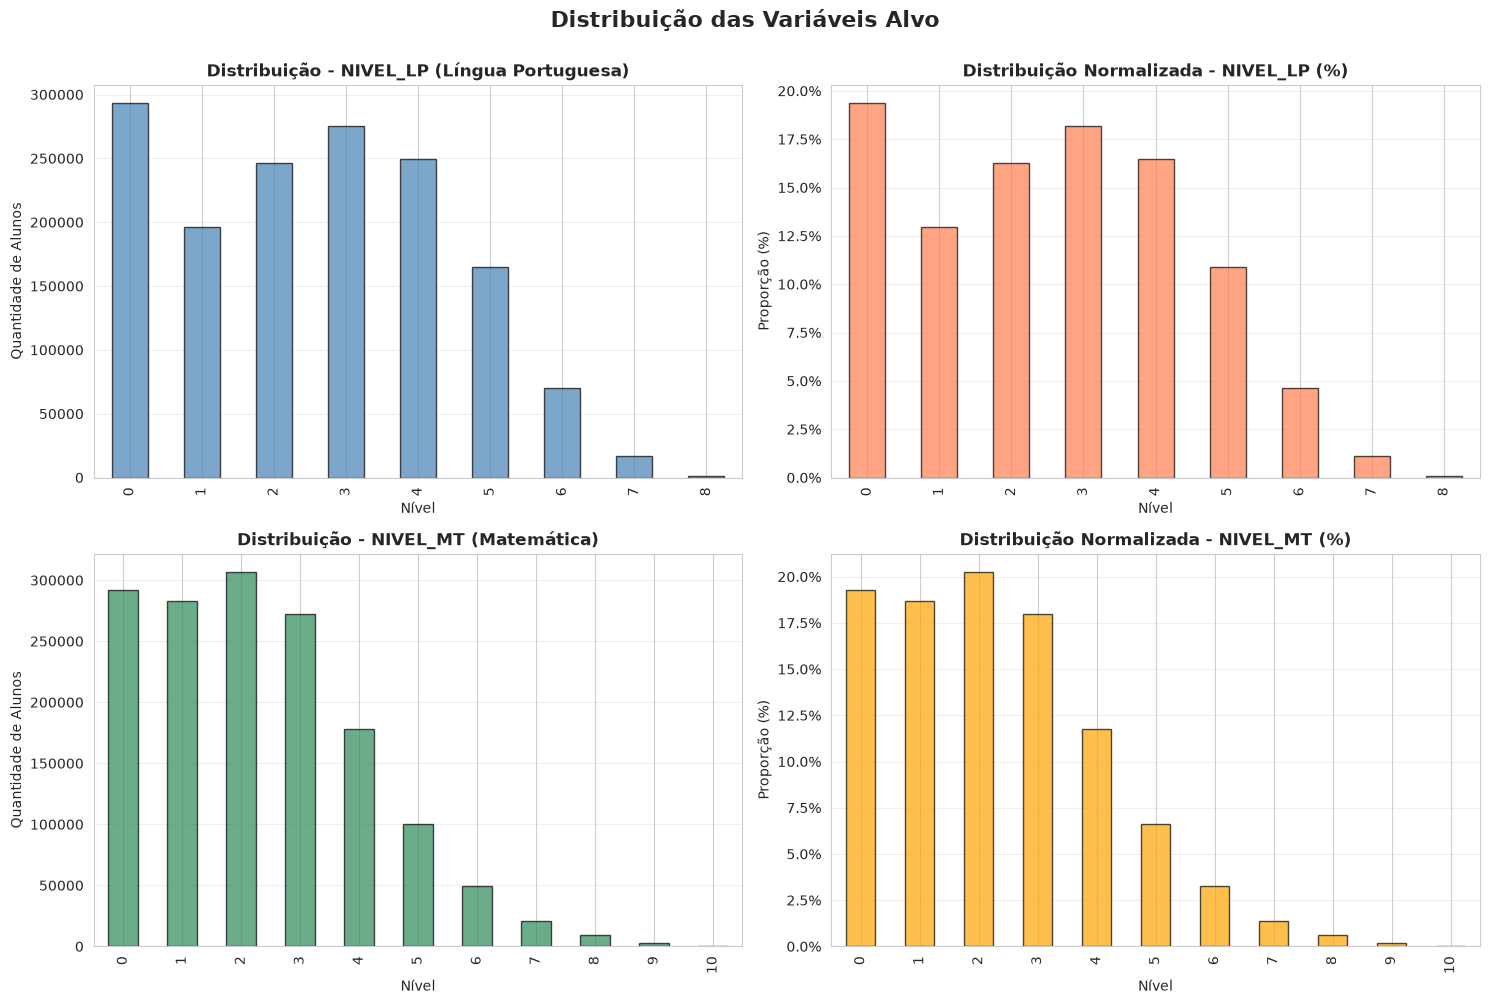

In [17]:
# Configurar estilo do seaborn
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Criar subplots para as distribuições das variáveis alvo
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribuição das Variáveis Alvo', fontsize=16, fontweight='bold', y=1.00)

if 'NIVEL_LP' in df_final.columns:
    # Histograma - NIVEL_LP
    ax1 = axes[0, 0]
    df_final['NIVEL_LP'].value_counts().sort_index().plot(
        kind='bar', ax=ax1, color='steelblue', edgecolor='black', alpha=0.7
    )
    ax1.set_title('Distribuição - NIVEL_LP (Língua Portuguesa)', fontweight='bold', fontsize=12)
    ax1.set_xlabel('Nível')
    ax1.set_ylabel('Quantidade de Alunos')
    ax1.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_LP
    ax2 = axes[0, 1]
    df_final['NIVEL_LP'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax2, color='coral', edgecolor='black', alpha=0.7
    )
    ax2.set_title('Distribuição Normalizada - NIVEL_LP (%)', fontweight='bold', fontsize=12)
    ax2.set_xlabel('Nível')
    ax2.set_ylabel('Proporção (%)')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax2.grid(axis='y', alpha=0.3)

if 'NIVEL_MT' in df_final.columns:
    # Histograma - NIVEL_MT
    ax3 = axes[1, 0]
    df_final['NIVEL_MT'].value_counts().sort_index().plot(
        kind='bar', ax=ax3, color='seagreen', edgecolor='black', alpha=0.7
    )
    ax3.set_title('Distribuição - NIVEL_MT (Matemática)', fontweight='bold', fontsize=12)
    ax3.set_xlabel('Nível')
    ax3.set_ylabel('Quantidade de Alunos')
    ax3.grid(axis='y', alpha=0.3)
    
    # Histograma normalizado - NIVEL_MT
    ax4 = axes[1, 1]
    df_final['NIVEL_MT'].value_counts(normalize=True).sort_index().plot(
        kind='bar', ax=ax4, color='orange', edgecolor='black', alpha=0.7
    )
    ax4.set_title('Distribuição Normalizada - NIVEL_MT (%)', fontweight='bold', fontsize=12)
    ax4.set_xlabel('Nível')
    ax4.set_ylabel('Proporção (%)')
    ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
    ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


*Análise de correlações*

Vamos examinar as correlações entre as features numéricas e as variáveis alvo.

In [18]:
print("\n" + "=" * 80)
print("ANÁLISE DE CORRELAÇÕES")
print("=" * 80)

# Calcular correlações para variáveis numéricas
numeric_cols_all = df_final.select_dtypes(include=[np.number]).columns.tolist()

# Calcular matriz de correlação
corr_matrix = df_final[numeric_cols_all].corr()

# Correlações com NIVEL_LP
if 'NIVEL_LP' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_LP:")
    corr_lp = corr_matrix['NIVEL_LP'].drop('NIVEL_LP').sort_values(ascending=False)
    corr_lp = corr_lp[corr_lp.index != 'NIVEL_MT']  # Remover correlação com MT
    corr_lp = corr_lp[~corr_lp.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_lp.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlações com NIVEL_MT
if 'NIVEL_MT' in corr_matrix.columns:
    print("\n◉ Top 10 Features com maior Correlação com NIVEL_MT:")
    corr_mt = corr_matrix['NIVEL_MT'].drop('NIVEL_MT').sort_values(ascending=False)
    corr_mt = corr_mt[corr_mt.index != 'NIVEL_LP']  # Remover correlação com LP
    corr_mt = corr_mt[~corr_mt.index.str.contains('ID_')]  # Remover IDs
    
    print(f"   {'Feature':<30} {'Correlação':>12}")
    print("   " + "-" * 45)
    for i, (feat, val) in enumerate(corr_mt.head(10).items(), 1):
        print(f"   {i:2d}. {feat:<27} {val:>12.4f}")

# Correlação entre as variáveis alvo
if 'NIVEL_LP' in corr_matrix.columns and 'NIVEL_MT' in corr_matrix.columns:
    corr_lp_mt = corr_matrix.loc['NIVEL_LP', 'NIVEL_MT']
    print(f"\n◉ Correlação entre NIVEL_LP e NIVEL_MT: {corr_lp_mt:.4f}")
    if corr_lp_mt > 0.7:
        print("   -  Correlação forte: os níveis de proficiência em LP e MT estão altamente relacionados")
    elif corr_lp_mt > 0.3:
        print("   -  Correlação moderada: existe relação entre LP e MT")
    else:
        print("   -  Correlação fraca: LP e MT são relativamente independentes")



ANÁLISE DE CORRELAÇÕES

◉ Top 10 Features com maior Correlação com NIVEL_LP:
   Feature                          Correlação
   ---------------------------------------------
    1. MEDIA_EM_NIVEL_LP                 0.3785
    2. MEDIA_EM_NIVEL_MT                 0.3421
    3. TX_RESP_Q11b                      0.1093
    4. TX_Q035                           0.1019
    5. TX_RESP_Q11a                      0.0983
    6. PC_FORMACAO_DOCENTE_MEDIO         0.0920
    7. TX_Q108                           0.0848
    8. TX_RESP_Q07a                      0.0847
    9. TX_Q119                           0.0661
   10. TX_Q036                           0.0653

◉ Top 10 Features com maior Correlação com NIVEL_MT:
   Feature                          Correlação
   ---------------------------------------------
    1. MEDIA_EM_NIVEL_MT                 0.3931
    2. MEDIA_EM_NIVEL_LP                 0.3554
    3. TX_Q035                           0.0978
    4. TX_Q108                           0.0857
    

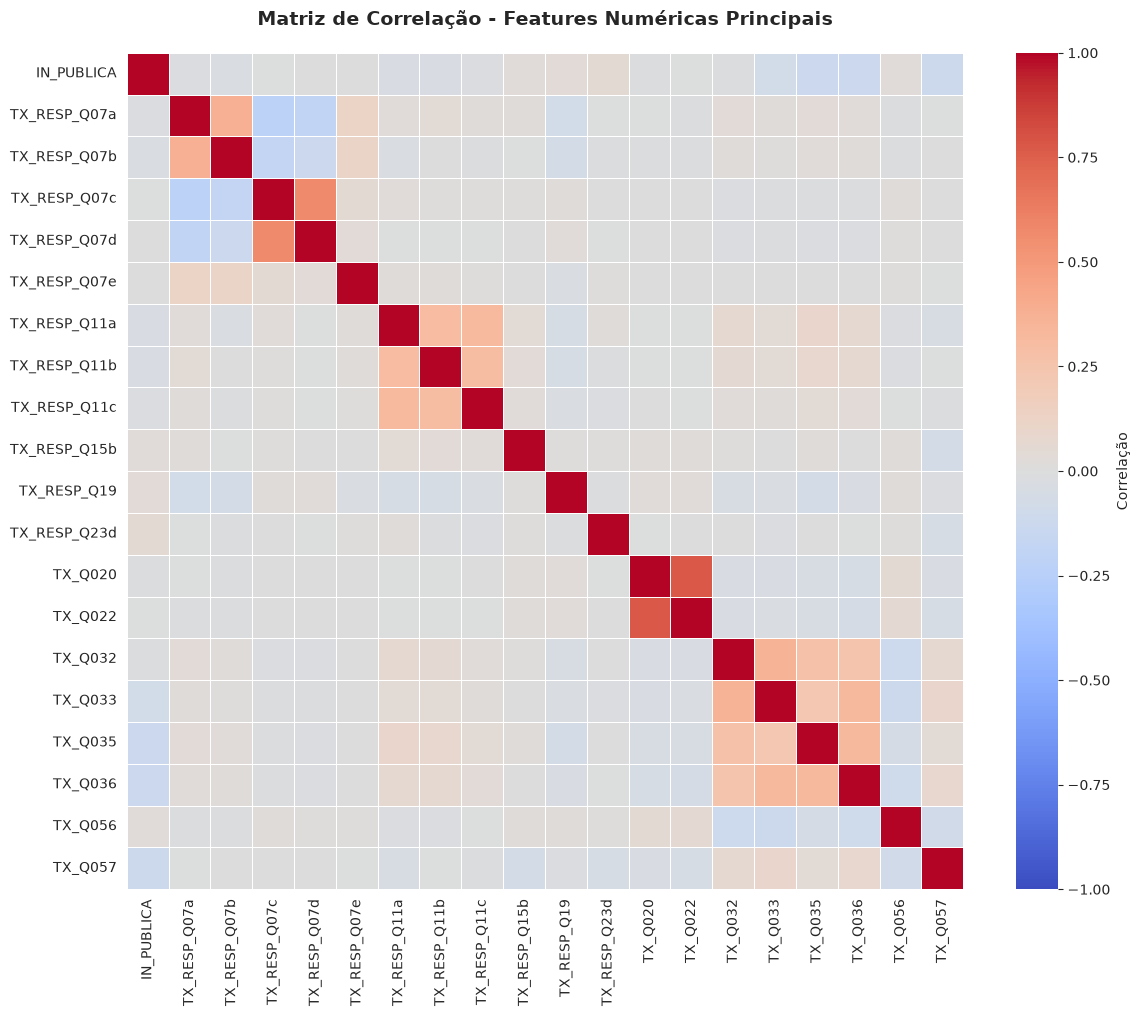

In [19]:
# Visualizar matriz de correlação (primeiras features)
if 'NIVEL_LP' in df_final.columns or 'NIVEL_MT' in df_final.columns:
    # Selecionar apenas as colunas numéricas relevantes (não IDs)
    cols_para_corr = [col for col in numeric_cols_all if not col.startswith('ID_')][:20]
    
    plt.figure(figsize=(12, 10))
    corr_subset = df_final[cols_para_corr].corr()
    
    sns.heatmap(
        corr_subset,
        annot=False,
        cmap='coolwarm',
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={'label': 'Correlação'},
        vmin=-1, vmax=1
    )
    
    plt.title('Matriz de Correlação - Features Numéricas Principais', fontweight='bold', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

*Principais características do dataset*

In [20]:
print("\n" + "=" * 80)
print("RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA")
print("=" * 80)

# Resumo geral
print("\n◉ DATASET SUMMARY:")
print(f"   • Total de amostras: {len(df_final):,}")
print(f"   • Total de features: {len(df_final.columns)}")
print(f"   • Features numéricas: {len(numeric_cols_all)}")
print(f"   • Features categóricas: {len(categorical_cols)}")

# Avaliar completude dos dados
missing_percentage = (df_final.isnull().sum().sum() / (len(df_final) * len(df_final.columns))) * 100
print("\n◉ QUALIDADE DOS DADOS:")
print(f"   • Completude geral: {100 - missing_percentage:.2f}%")
print(f"   • Dados ausentes: {missing_percentage:.2f}%")

if missing_percentage < 5:
    print("   ✓ Qualidade Excelente! Menos de 5% de dados ausentes")
elif missing_percentage < 20:
    print("   !  Qualidade Boa. Será necessário imputação de dados")
else:
    print("   !  Atenção: Significativa quantidade de dados ausentes")

# Análise das variáveis alvo
print("\n◉ VARIÁVEIS ALVO:")
if 'NIVEL_LP' in df_final.columns:
    unique_lp = df_final['NIVEL_LP'].nunique()
    print(f"   • NIVEL_LP: {unique_lp} classes (Nível 0-8)")
    
    # Verificar balanceamento
    lp_counts = df_final['NIVEL_LP'].value_counts()
    lp_ratio = lp_counts.max() / lp_counts.min()
    if lp_ratio < 3:
        print(f"      ✓ Balanceamento: Bom (proporção máx/min = {lp_ratio:.2f})")
    elif lp_ratio < 10:
        print(f"      !  Balanceamento: Moderado (proporção máx/min = {lp_ratio:.2f})")
    else:
        print(f"      !  Balanceamento: Desbalanceado (proporção máx/min = {lp_ratio:.2f})")

if 'NIVEL_MT' in df_final.columns:
    unique_mt = df_final['NIVEL_MT'].nunique()
    print(f"   • NIVEL_MT: {unique_mt} classes (Nível 0-10)")
    
    # Verificar balanceamento
    mt_counts = df_final['NIVEL_MT'].value_counts()
    mt_ratio = mt_counts.max() / mt_counts.min()
    if mt_ratio < 3:
        print(f"      ✓ Balanceamento: Bom (proporção máx/min = {mt_ratio:.2f})")
    elif mt_ratio < 10:
        print(f"      !  Balanceamento: Moderado (proporção máx/min = {mt_ratio:.2f})")
    else:
        print(f"      !  Balanceamento: Desbalanceado (proporção máx/min = {mt_ratio:.2f})")



RESUMO EXECUTIVO DA ANÁLISE EXPLORATÓRIA

◉ DATASET SUMMARY:
   • Total de amostras: 1,514,448
   • Total de features: 80
   • Features numéricas: 52
   • Features categóricas: 28

◉ QUALIDADE DOS DADOS:
   • Completude geral: 89.70%
   • Dados ausentes: 10.30%
   !  Qualidade Boa. Será necessário imputação de dados

◉ VARIÁVEIS ALVO:
   • NIVEL_LP: 9 classes (Nível 0-8)
      !  Balanceamento: Desbalanceado (proporção máx/min = 244.23)
   • NIVEL_MT: 11 classes (Nível 0-10)
      !  Balanceamento: Desbalanceado (proporção máx/min = 3880.11)


*Preenchimento dos valores nulos do dataset final*

Após a análise exploratória de dados, percebe-se que existem uma quantidade de valores ausentes considerável para o dataset. Realizamos, portanto, o tratamento de valores ausentes no conjunto de dados utilizando estratégias diferentes conforme o tipo de variável. Para variáveis numéricas (como médias de proficiência e medidas contínuas), foi aplicada a imputação pela mediana, geralmente agrupada por UF ou município. Já para variáveis categóricas (como características do aluno, família e infraestrutura escolar), foi utilizada a moda, também segmentada por UF, município ou escola quando apropriado, preservando padrões regionais e contextuais dos dados ao máximo. Após a etapa de imputação, as linhas que ainda continham valores ausentes foram removidas com dropna, garantindo a integridade final do dataset. 

In [21]:
# Verificando a quantidade de dados ausentes
print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_final.shape[0]:,}")

print("\n◉ Valores Ausentes (Missing Values):")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("  ✓ Nenhum valor ausente detectado!")


◉ Dimensões do Dataset:
   Linhas (amostras): 1,514,448

◉ Valores Ausentes (Missing Values):
                           Ausentes  Percentual (%)
TX_RESP_Q09                  404299       26.696130
TX_RESP_Q07d                 396942       26.210342
TX_RESP_Q07c                 367739       24.282049
MEDIA_EM_NIVEL_MT            331568       21.893654
MEDIA_EM_NIVEL_LP            331568       21.893654
TX_Q022                      290322       19.170153
TX_Q087                      289785       19.134695
TX_Q035                      288749       19.066287
TX_Q020                      288545       19.052817
TX_Q082                      288220       19.031357
TX_Q208                      287874       19.008510
TX_Q079                      286518       18.918972
TX_Q083                      286468       18.915671
TX_Q085                      286370       18.909200
TX_Q078                      286160       18.895333
TX_Q033                      285186       18.831020
TX_Q036              

In [22]:
# Preenchendo MEDIA_EM_NIVEL_MT - média de proficiência em Matemática do EM (escala SAEB) por escola - 21.89% faltando -> mediana por UF
df_final['MEDIA_EM_NIVEL_MT'] = df_final.groupby('ID_UF')['MEDIA_EM_NIVEL_MT'].transform(
    lambda x: x.fillna(x.median())
)

# Preenchendo MEDIA_EM_NIVEL_LP - média de proficiência em Língua Portuguesa do EM (escala SAEB) por escola - 21.89% faltando -> mediana por UF
df_final['MEDIA_EM_NIVEL_LP'] = df_final.groupby('ID_UF')['MEDIA_EM_NIVEL_LP'].transform(
    lambda x: x.fillna(x.median())
)

# Preenchendo TX_RESP_Q01 - sexo do aluno - 1.07% faltando -> moda por UF
df_final['TX_RESP_Q01'] = df_final.groupby('ID_UF')['TX_RESP_Q01'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchando TX_RESP_Q02 - idade do aluno - 3.07% faltando -> moda por UF
df_final['TX_RESP_Q02'] = df_final.groupby('ID_UF')['TX_RESP_Q02'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q03 - língua falada pelos pais em casa - 1.22% faltando -> moda por UF
df_final['TX_RESP_Q03'] = df_final.groupby('ID_UF')['TX_RESP_Q03'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q04 - cor ou raça do aluno - 2.63% faltando -> moda por UF
df_final['TX_RESP_Q04'] = df_final.groupby('ID_UF')['TX_RESP_Q04'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q05a - possui deficiência - 2.36% faltando -> moda geral
df_final['TX_RESP_Q05a'] = df_final['TX_RESP_Q05a'].fillna(df_final['TX_RESP_Q05a'].mode().iloc[0])

# Preenchendo TX_RESP_Q05b - possui transtorno do espectro autista - 4.00% faltando -> moda geral
df_final['TX_RESP_Q05b'] = df_final['TX_RESP_Q05b'].fillna(df_final['TX_RESP_Q05b'].mode().iloc[0])

# Preenchendo TX_RESP_Q05c - possui altas habilidades ou superdotação - 4.41% faltando -> moda geral
df_final['TX_RESP_Q05c'] = df_final['TX_RESP_Q05c'].fillna(df_final['TX_RESP_Q05c'].mode().iloc[0])

# Preenchendo TX_RESP_Q06 - número de pessoas que moram na casa do aluno - 2.23% faltando -> moda por UF
df_final['TX_RESP_Q06'] = df_final.groupby('ID_UF')['TX_RESP_Q06'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07a - mora com mãe(s) ou madrasta(s) - 5.96% faltando -> moda por UF
df_final['TX_RESP_Q07a'] = df_final.groupby('ID_UF')['TX_RESP_Q07a'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07b - mora com pai(s) ou padrasto(s) - 10.02% faltando -> moda por UF
df_final['TX_RESP_Q07b'] = df_final.groupby('ID_UF')['TX_RESP_Q07b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07c - mora com avó(s) - 24.28% faltando -> moda por UF
df_final['TX_RESP_Q07c'] = df_final.groupby('ID_UF')['TX_RESP_Q07c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07d - mora com avô(s) - 26.21% faltando -> moda por UF
df_final['TX_RESP_Q07d'] = df_final.groupby('ID_UF')['TX_RESP_Q07d'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q07e - mora com outros familiares (irmãos, tios, primos etc.) - 10.82% faltando -> moda por UF
df_final['TX_RESP_Q07e'] = df_final.groupby('ID_UF')['TX_RESP_Q07e'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q08 - maior escolaridade da mãe/responsável feminina - 14.57% faltando -> moda por município
df_final['TX_RESP_Q08'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q08'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q09 - maior escolaridade do pai/responsável masculino - 26.70% faltando -> moda por municipio
df_final['TX_RESP_Q09'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q09'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10a - frequência com que pais leem em casa - 2.09% faltando -> moda por UF
df_final['TX_RESP_Q10a'] = df_final.groupby('ID_UF')['TX_RESP_Q10a'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10b - frequência com que pais conversam sobre o que ocorre na escola - 2.23% faltando -> moda por UF
df_final['TX_RESP_Q10b'] = df_final.groupby('ID_UF')['TX_RESP_Q10b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10c - frequência com que pais incentivam o aluno a estudar - 2.25% faltando -> moda por UF
df_final['TX_RESP_Q10c'] = df_final.groupby('ID_UF')['TX_RESP_Q10c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10d - frequência com que pais incentivam a fazer tarefa de casa - 2.52% faltando -> moda por UF
df_final['TX_RESP_Q10d'] = df_final.groupby('ID_UF')['TX_RESP_Q10d'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10e - frequência com que pais incentivam a comparecer às aulas - 2.62% faltando -> moda por UF
df_final['TX_RESP_Q10e'] = df_final.groupby('ID_UF')['TX_RESP_Q10e'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q10f - frequência com que pais vão às reuniões de pais - 2.12% faltando -> moda por UF
df_final['TX_RESP_Q10f'] = df_final.groupby('ID_UF')['TX_RESP_Q10f'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q11a - rua do aluno tem asfalto ou calçamento - 1.29% faltando -> moda por município
df_final['TX_RESP_Q11a'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q11a'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q11b - rua do aluno tem água tratada - 2.17% faltando -> moda por município
df_final['TX_RESP_Q11b'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q11b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q11c - rua do aluno tem iluminação - 1.97% faltando -> moda por município
df_final['TX_RESP_Q11c'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q11c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q12b - quantidade de computadores/notebooks em casa - 7.99% faltando -> moda por UF
df_final['TX_RESP_Q12b'] = df_final.groupby('ID_UF')['TX_RESP_Q12b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q12c - quantidade de quartos para dormir em casa - 6.40% faltando -> moda por UF
df_final['TX_RESP_Q12c'] = df_final.groupby('ID_UF')['TX_RESP_Q12c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q14 - tempo de deslocamento até a escola - 7.12% faltando -> moda por município
df_final['TX_RESP_Q14'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q14'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q15b - utiliza passe escolar para ir à escola - 10.07% faltando -> moda por município
df_final['TX_RESP_Q15b'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q15b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q16 - forma habitual de chegar à escola - 14.93% faltando -> moda por município
df_final['TX_RESP_Q16'] = df_final.groupby('ID_MUNICIPIO')['TX_RESP_Q16'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q17 - idade de entrada na escola - 5.34% faltando -> moda por UF
df_final['TX_RESP_Q17'] = df_final.groupby('ID_UF')['TX_RESP_Q17'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q18 - tipo de escola frequentada desde o 1º ano do EF - 5.29% faltando -> moda por UF
df_final['TX_RESP_Q18'] = df_final.groupby('ID_UF')['TX_RESP_Q18'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q19 - já foi reprovado(a) - 5.28% faltando -> moda por UF
df_final['TX_RESP_Q19'] = df_final.groupby('ID_UF')['TX_RESP_Q19'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)   
# Preenchendo TX_RESP_Q21a - tempo fora da escola para estudar/lição de casa - 5.30% faltando -> moda por UF
df_final['TX_RESP_Q21a'] = df_final.groupby('ID_UF')['TX_RESP_Q21a'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q21b - tempo fora da escola para atividades extracurriculares - 6.77% faltando -> moda por UF
df_final['TX_RESP_Q21b'] = df_final.groupby('ID_UF')['TX_RESP_Q21b'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q21c - tempo fora da escola para trabalhar em casa - 6.06% faltando -> moda por UF
df_final['TX_RESP_Q21c'] = df_final.groupby('ID_UF')['TX_RESP_Q21c'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q21d - tempo fora da escola para trabalhar fora de casa - 6.09% faltando -> moda por UF
df_final['TX_RESP_Q21d'] = df_final.groupby('ID_UF')['TX_RESP_Q21d'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q21e - tempo fora da escola para lazer (TV, internet, música etc.) - 5.53% faltando -> moda por UF
df_final['TX_RESP_Q21e'] = df_final.groupby('ID_UF')['TX_RESP_Q21e'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)  

# Preenchendo TX_RESP_Q23d - sente-se seguro(a) na escola - 2.80% faltando -> moda por escola
df_final['TX_RESP_Q23d'] = df_final.groupby('ID_ESCOLA')['TX_RESP_Q23d'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_RESP_Q24 - pretensão ao terminar o ensino médio - 2.30% faltando -> moda por UF
df_final['TX_RESP_Q24'] = df_final.groupby('ID_UF')['TX_RESP_Q24'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q020 - horas semanais dedicadas pelo diretor a liderar equipes de trabalho(19,05% faltando) -> mediana por município
df_final['TX_Q020'] = df_final.groupby('ID_MUNICIPIO')['TX_Q020'].transform(
    lambda x: x.fillna(x.median())
)

# Preenchendo TX_Q022 - horas semanais dedicadas pelo diretor ao atendimento da comunidade escolar(19,17% faltando) -> mediana por município
df_final['TX_Q022'] = df_final.groupby('ID_MUNICIPIO')['TX_Q022'].transform(
    lambda x: x.fillna(x.median())
)

# Preenchendo TX_Q032 - condição de uso das televisões da escola(18,81% faltando) -> moda por município
df_final['TX_Q032'] = df_final.groupby('ID_MUNICIPIO')['TX_Q032'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q033 - condição de uso dos projetores multimídia (datashow)(18,83% faltando) -> moda por município
df_final['TX_Q033'] = df_final.groupby('ID_MUNICIPIO')['TX_Q033'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q035 - condição de uso dos softwares educacionais(19,07% faltando) -> moda por município
df_final['TX_Q035'] = df_final.groupby('ID_MUNICIPIO')['TX_Q035'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q036 - condição de uso da internet banda larga(18,83% faltando) -> moda por município
df_final['TX_Q036'] = df_final.groupby('ID_MUNICIPIO')['TX_Q036'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q056 - houve atraso no repasse de recursos financeiros para pagamento de pessoal(18,60% faltando) -> moda por município
df_final['TX_Q056'] = df_final.groupby('ID_MUNICIPIO')['TX_Q056'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q057 - o quadro de professores da escola estava completo(18,15% faltando) -> moda por município
df_final['TX_Q057'] = df_final.groupby('ID_MUNICIPIO')['TX_Q057'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q078 - calendário escolar interrompido por falta de água(18,90% faltando) -> moda por município
df_final['TX_Q078'] = df_final.groupby('ID_MUNICIPIO')['TX_Q078'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q079 - calendário escolar interrompido por falta de energia elétrica(18,92% faltando) -> moda por município
df_final['TX_Q079'] = df_final.groupby('ID_MUNICIPIO')['TX_Q079'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q081 - calendário escolar interrompido por greve de professores(18,52% faltando) -> moda por município
df_final['TX_Q081'] = df_final.groupby('ID_MUNICIPIO')['TX_Q081'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q082 - calendário escolar interrompido por episódios de violência(19,03% faltando) -> moda por município
df_final['TX_Q082'] = df_final.groupby('ID_MUNICIPIO')['TX_Q082'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q083 - calendário escolar interrompido por problemas de infraestrutura predial (18,92% faltando) -> moda por município
df_final['TX_Q083'] = df_final.groupby('ID_MUNICIPIO')['TX_Q083'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q085 - calendário escolar interrompido por eventos climáticos(18,91% faltando) -> moda por município
df_final['TX_Q085'] = df_final.groupby('ID_MUNICIPIO')['TX_Q085'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q087 - calendário escolar interrompido por problemas de saúde pública(19,13% faltando) -> moda por município
df_final['TX_Q087'] = df_final.groupby('ID_MUNICIPIO')['TX_Q087'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q108 - condição de uso dos equipamentos da área externa de recreação(18,12% faltando) -> moda por município
df_final['TX_Q108'] = df_final.groupby('ID_MUNICIPIO')['TX_Q108'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q119 - escola é militar ou militarizada(18,37% faltando) -> moda por município
df_final['TX_Q119'] = df_final.groupby('ID_MUNICIPIO')['TX_Q119'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q129 - escola recebe recursos federais como fonte de financiamento(18,29% faltando) -> moda por município
df_final['TX_Q129'] = df_final.groupby('ID_MUNICIPIO')['TX_Q129'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q130 - escola recebe recursos estaduais ou municipais como fonte de financiamento(18,54% faltando) -> moda por município
df_final['TX_Q130'] = df_final.groupby('ID_MUNICIPIO')['TX_Q130'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q139 - escola oferece merenda aos estudantes(18,49% faltando) -> moda por município
df_final['TX_Q139'] = df_final.groupby('ID_MUNICIPIO')['TX_Q139'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q191 - eficácia do contato com familiares para reduzir abandono escolar(18,48% faltando) -> moda por município
df_final['TX_Q191'] = df_final.groupby('ID_MUNICIPIO')['TX_Q191'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q194 - escola possui projetos de ciência e tecnologia(18,50% faltando) -> moda por município
df_final['TX_Q194'] = df_final.groupby('ID_MUNICIPIO')['TX_Q194'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q203 - escola possui projetos sobre uso de drogas(18,32% faltando) -> moda por município
df_final['TX_Q203'] = df_final.groupby('ID_MUNICIPIO')['TX_Q203'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q205 - escola realiza preparação para avaliações externas(18,32% faltando) -> moda por município
df_final['TX_Q205'] = df_final.groupby('ID_MUNICIPIO')['TX_Q205'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q206 - escola inscreve alunos em olimpíadas de conhecimento(18,36% faltando) -> moda por município
df_final['TX_Q206'] = df_final.groupby('ID_MUNICIPIO')['TX_Q206'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q207 - escola realiza feira de ciências(18,57% faltando) -> moda por município
df_final['TX_Q207'] = df_final.groupby('ID_MUNICIPIO')['TX_Q207'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q208 - escola realiza feira de artes(19,01% faltando) -> moda por município
df_final['TX_Q208'] = df_final.groupby('ID_MUNICIPIO')['TX_Q208'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Preenchendo TX_Q209 - escola realiza campeonatos esportivos (18,37% faltando) -> moda por município
df_final['TX_Q209'] = df_final.groupby('ID_MUNICIPIO')['TX_Q209'].transform(
    lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# Eliminando linhas que possuem pelo menos um valor ausente após preenchimento
df_final = df_final.dropna(axis=0, how='any')

# Verificando a quantidade de dados ausentes após o preenchimento
print("\n◉ Dimensões do Dataset:")
print(f"   Linhas (amostras): {df_final.shape[0]:,}")
print("\n◉ Valores Ausentes (Missing Values):")
missing = df_final.isnull().sum()
missing_pct = (missing / len(df_final)) * 100
missing_df = pd.DataFrame({
    'Ausentes': missing,
    'Percentual (%)': missing_pct
}).sort_values('Ausentes', ascending=False)
missing_df = missing_df[missing_df['Ausentes'] > 0]

if len(missing_df) > 0:
    print(missing_df.to_string())
else:
    print("  ✓ Nenhum valor ausente detectado!")



◉ Dimensões do Dataset:
   Linhas (amostras): 1,428,294

◉ Valores Ausentes (Missing Values):
  ✓ Nenhum valor ausente detectado!


In [23]:
from sklearn.model_selection import train_test_split

df_treino = df_final.copy()  # Criando uma cópia do DataFrame final para treino
df_treino = df_treino[(df_treino['NIVEL_LP'] != 0) & (df_treino['NIVEL_MT'] != 0)]

# Diminuindo amostragem para 20%
FRAC = 0.20

df_treino, _ = train_test_split(df_treino, test_size=1 - FRAC, stratify=df_treino['NIVEL_LP'], random_state=42)
print(f"Dataset reduzido: {len(df_treino):,} linhas ({FRAC*100:.0f}% do original)")

Dataset reduzido: 199,626 linhas (20% do original)


# Treinamento dos modelos

Esta seção usa as funções reutilizáveis de `src/modelagem.py` e `src/modelos.py` para treinar os mesmos algoritmos para os dois alvos do projeto: `NIVEL_LP` e `NIVEL_MT`. O pipeline centralizado remove colunas de identificação e vazamento, aplica imputação, codificação categórica, validação cruzada estratificada por escola e preserva os rótulos originais das classes.


In [24]:
from pathlib import Path
import gc
import pickle
import shutil
import sys
from datetime import datetime

import pandas as pd

repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.modelagem import treinar_modelo
from src.modelos import (
    criar_arvore_decisao,
    criar_knn,
    criar_random_forest,
    criar_regressao_logistica,
    criar_xgboost,
)

ALVOS = ["NIVEL_LP", "NIVEL_MT"]
FABRICAS_MODELOS = {
    "Regressão Logística": criar_regressao_logistica,
    "KNN": criar_knn,
    "Árvore de Decisão": criar_arvore_decisao,
    "Random Forest": criar_random_forest,
    "XGBoost": criar_xgboost,
}

ALVOS_ATIVOS = ["NIVEL_LP", "NIVEL_MT"]
MODELOS_ATIVOS = [
    "Regressão Logística",
    "KNN",
    "Árvore de Decisão",
    "Random Forest",
    "XGBoost",
]

GRID_N_JOBS = 1
MAX_SPLITS_TESTE = 7
MAX_SPLITS_VALIDACAO = 3
CHECKPOINT_PATH = repo_root / "artefatos" / "resultados_modelagem.pkl"
RESUMO_CSV_PATH = repo_root / "artefatos" / "resumo_modelos.csv"
RESUMIR_EXECUCAO = True
LIMPAR_COLETAR_GC = True


def checkpoint_vazio() -> dict[str, dict[str, object]]:
    return {alvo: {} for alvo in ALVOS_ATIVOS}


def nome_checkpoint_corrompido(caminho_checkpoint: Path) -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return caminho_checkpoint.with_name(
        f"{caminho_checkpoint.stem}.corrompido_{timestamp}{caminho_checkpoint.suffix}"
    )


def carregar_checkpoint(caminho_checkpoint: Path) -> dict[str, dict[str, object]]:
    if not caminho_checkpoint.exists():
        return checkpoint_vazio()

    try:
        with caminho_checkpoint.open("rb") as arquivo:
            resultados_salvos = pickle.load(arquivo)
    except (EOFError, pickle.UnpicklingError, AttributeError, ValueError) as erro:
        caminho_backup = nome_checkpoint_corrompido(caminho_checkpoint)
        shutil.move(str(caminho_checkpoint), str(caminho_backup))
        print(
            "Checkpoint inválido ignorado. "
            f"Arquivo movido para {caminho_backup.name}. "
            f"Motivo: {type(erro).__name__}: {erro}"
        )
        return checkpoint_vazio()

    resultados_filtrados = checkpoint_vazio()
    for alvo in ALVOS_ATIVOS:
        modelos_salvos = resultados_salvos.get(alvo, {})
        for nome_modelo in MODELOS_ATIVOS:
            if nome_modelo in modelos_salvos:
                resultados_filtrados[alvo][nome_modelo] = modelos_salvos[nome_modelo]

    return resultados_filtrados


def construir_resumo_modelos(resultados_treinados: dict[str, dict[str, object]]) -> pd.DataFrame:
    linhas_resumo = []

    for alvo in ALVOS_ATIVOS:
        for nome_modelo in MODELOS_ATIVOS:
            resultado = resultados_treinados.get(alvo, {}).get(nome_modelo)
            if resultado is None:
                continue

            linhas_resumo.append(
                {
                    "alvo": alvo,
                    "modelo": nome_modelo,
                    **resultado.metricas_resumo,
                    "melhores_parametros": resultado.melhores_parametros,
                }
            )

    if not linhas_resumo:
        return pd.DataFrame()

    return (
        pd.DataFrame(linhas_resumo)
        .sort_values(["alvo", "f1_macro_teste"], ascending=[True, False])
        .reset_index(drop=True)
    )


def salvar_resultados(resultados_treinados: dict[str, dict[str, object]]) -> pd.DataFrame:
    CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
    caminho_temporario = CHECKPOINT_PATH.with_suffix(f"{CHECKPOINT_PATH.suffix}.tmp")

    with caminho_temporario.open("wb") as arquivo:
        pickle.dump(resultados_treinados, arquivo, protocol=pickle.HIGHEST_PROTOCOL)

    caminho_temporario.replace(CHECKPOINT_PATH)

    resumo_atual = construir_resumo_modelos(resultados_treinados)
    resumo_atual.to_csv(RESUMO_CSV_PATH, index=False)
    return resumo_atual


## Preparação da base de modelagem

O notebook já cria `df_treino` na etapa anterior. Caso a célula seja executada isoladamente depois do pré-processamento, usamos `df_final` como alternativa e aplicamos a mesma remoção de classes zeradas dos alvos.


In [25]:
if "df_treino" in globals():
    df_modelagem = df_treino.copy()
elif "df_final" in globals():
    df_modelagem = df_final.copy()
    df_modelagem = df_modelagem[
        (df_modelagem["NIVEL_LP"] != 0) & (df_modelagem["NIVEL_MT"] != 0)
    ]
else:
    raise NameError(
        "Execute primeiro as células de pré-processamento para criar df_final ou df_treino."
    )

colunas_obrigatorias = ["ID_ESCOLA", *ALVOS_ATIVOS]
faltantes = [
    coluna for coluna in colunas_obrigatorias if coluna not in df_modelagem.columns
]
if faltantes:
    raise ValueError(f"Colunas obrigatórias ausentes para modelagem: {faltantes}")

modelos_invalidos = [
    nome_modelo for nome_modelo in MODELOS_ATIVOS if nome_modelo not in FABRICAS_MODELOS
]
if modelos_invalidos:
    raise ValueError(f"Modelos ativos inválidos: {modelos_invalidos}")

alvos_invalidos = [alvo for alvo in ALVOS_ATIVOS if alvo not in ALVOS]
if alvos_invalidos:
    raise ValueError(f"Alvos ativos inválidos: {alvos_invalidos}")

if GRID_N_JOBS < 1:
    raise ValueError("GRID_N_JOBS deve ser maior ou igual a 1.")
if MAX_SPLITS_TESTE < 2:
    raise ValueError("MAX_SPLITS_TESTE deve ser maior ou igual a 2.")
if MAX_SPLITS_VALIDACAO < 2:
    raise ValueError("MAX_SPLITS_VALIDACAO deve ser maior ou igual a 2.")

df_modelagem = df_modelagem.dropna(subset=colunas_obrigatorias).copy()

print(
    f"Base de modelagem: {df_modelagem.shape[0]:,} linhas x {df_modelagem.shape[1]:,} colunas"
)
print(f"Alvos ativos: {ALVOS_ATIVOS}")
print(f"Modelos ativos: {MODELOS_ATIVOS}")
print(
    "Configuração de recursos: "
    f"GridSearchCV n_jobs={GRID_N_JOBS}, "
    f"max_splits_teste={MAX_SPLITS_TESTE}, "
    f"max_splits_validacao={MAX_SPLITS_VALIDACAO}"
)
print(f"Checkpoint: {CHECKPOINT_PATH}")

for alvo in ALVOS_ATIVOS:
    print(f"\nDistribuição de {alvo}:")
    print(df_modelagem[alvo].value_counts().sort_index())


Base de modelagem: 199,626 linhas x 80 colunas
Alvos ativos: ['NIVEL_LP', 'NIVEL_MT']
Modelos ativos: ['Regressão Logística', 'KNN', 'Árvore de Decisão', 'Random Forest', 'XGBoost']
Configuração de recursos: GridSearchCV n_jobs=1, max_splits_teste=7, max_splits_validacao=3
Checkpoint: /home/fg/repo/projiml/artefatos/resultados_modelagem.pkl

Distribuição de NIVEL_LP:
NIVEL_LP
1    26490
2    37750
3    45959
4    43781
5    29766
6    12687
7     2987
8      206
Name: count, dtype: int64

Distribuição de NIVEL_MT:
NIVEL_MT
1     38926
2     48715
3     47001
4     32086
5     18389
6      8908
7      3601
8      1543
9       443
10       14
Name: count, dtype: int64


## Treinamento de todos os modelos

Cada combinação de modelo e alvo passa pelo mesmo fluxo: separação de features sem vazamento, validação cruzada agrupada por `ID_ESCOLA`, busca de hiperparâmetros e ajuste final do melhor pipeline na base de modelagem.

A execução abaixo é sequencial, limitada por `GRID_N_JOBS` e com checkpoint em `artefatos/`. Se a sessão for interrompida, a célula pode ser executada novamente com `RESUMIR_EXECUCAO=True` para continuar apenas as combinações pendentes.


In [ ]:
if RESUMIR_EXECUCAO:
    resultados = carregar_checkpoint(CHECKPOINT_PATH)
    print(f"Checkpoint carregado de {CHECKPOINT_PATH}")
else:
    resultados = {alvo: {} for alvo in ALVOS_ATIVOS}
    print("Execução iniciada sem reaproveitar checkpoint anterior.")

resumo_modelos = construir_resumo_modelos(resultados)
if not resumo_modelos.empty:
    print("Combinações já concluídas:")
    display(resumo_modelos)

for alvo in ALVOS_ATIVOS:
    resultados.setdefault(alvo, {})

    for nome_modelo in MODELOS_ATIVOS:
        if nome_modelo in resultados[alvo]:
            print("\n" + "=" * 90)
            print(f"Ignorando {nome_modelo} para {alvo}: já salvo no checkpoint.")
            print("=" * 90)
            continue

        fabrica_modelo = FABRICAS_MODELOS[nome_modelo]

        print("\n" + "=" * 90)
        print(f"Treinando {nome_modelo} para {alvo}")
        print(
            "Configuração: "
            f"n_jobs={GRID_N_JOBS}, "
            f"splits_teste<={MAX_SPLITS_TESTE}, "
            f"splits_validacao<={MAX_SPLITS_VALIDACAO}"
        )
        print("=" * 90)

        resultado_treinamento = treinar_modelo(
            tabela=df_modelagem,
            alvo=alvo,
            fabrica_modelo=fabrica_modelo,
            grid_n_jobs=GRID_N_JOBS,
            max_splits_teste=MAX_SPLITS_TESTE,
            max_splits_validacao=MAX_SPLITS_VALIDACAO,
        )

        resultados[alvo][nome_modelo] = resultado_treinamento
        resumo_modelos = salvar_resultados(resultados)

        print("Melhores parâmetros:", resultado_treinamento.melhores_parametros)
        print("Métricas de resumo:")
        for metrica, valor in resultado_treinamento.metricas_resumo.items():
            if isinstance(valor, float):
                print(f"  {metrica}: {valor:.4f}")
            else:
                print(f"  {metrica}: {valor}")
        print(f"Checkpoint atualizado em {CHECKPOINT_PATH}")
        print(f"Resumo salvo em {RESUMO_CSV_PATH}")

        if LIMPAR_COLETAR_GC:
            del resultado_treinamento
            gc.collect()

if CHECKPOINT_PATH.exists():
    resultados = carregar_checkpoint(CHECKPOINT_PATH)
    resumo_modelos = construir_resumo_modelos(resultados)

resumo_modelos


Checkpoint inválido ignorado. Arquivo movido para resultados_modelagem.corrompido_20260625_031017.pkl. Motivo: EOFError: Ran out of input
Checkpoint carregado de /home/fg/repo/projiml/artefatos/resultados_modelagem.pkl

Treinando Regressão Logística para NIVEL_LP
Configuração: n_jobs=1, splits_teste<=7, splits_validacao<=3
Melhores parâmetros: {'modelo__C': 1.0}
Métricas de resumo:
  accuracy_validacao_media: 0.1769
  accuracy_validacao_desvio: 0.0018
  f1_macro_validacao_media: 0.1457
  f1_macro_validacao_desvio: 0.0010
  accuracy_teste: 0.1758
  f1_macro_teste: 0.1458
  n_splits_validacao: 3
Checkpoint atualizado em /home/fg/repo/projiml/artefatos/resultados_modelagem.pkl
Resumo salvo em /home/fg/repo/projiml/artefatos/resumo_modelos.csv

Treinando KNN para NIVEL_LP
Configuração: n_jobs=1, splits_teste<=7, splits_validacao<=3
Melhores parâmetros: {'modelo__n_neighbors': 7}
Métricas de resumo:
  accuracy_validacao_media: 0.2134
  accuracy_validacao_desvio: 0.0015
  f1_macro_validacao_

## Detalhe da validação e matrizes de confusão

As tabelas abaixo mostram as métricas por fold para cada combinação treinada, métricas adicionais derivadas do conjunto de teste e matrizes de confusão coloridas. As matrizes normalizadas por linha mostram a distribuição percentual das predições dentro de cada classe real, o que facilita interpretar o recall por classe.


In [6]:
from pathlib import Path
import pickle
import shutil
import sys
from datetime import datetime

import numpy as np
import pandas as pd

if "repo_root" not in globals():
    repo_root = Path.cwd()
    if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
        repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Necessario para o pickle resolver as classes salvas no checkpoint.
import src.modelagem  # noqa: F401

ALVOS_ATIVOS = globals().get("ALVOS_ATIVOS", ["NIVEL_LP", "NIVEL_MT"])
MODELOS_ATIVOS = globals().get(
    "MODELOS_ATIVOS",
    [
        "Regressão Logística",
        "KNN",
        "Árvore de Decisão",
        "Random Forest",
        "XGBoost",
    ],
)
CHECKPOINT_PATH = globals().get(
    "CHECKPOINT_PATH",
    repo_root / "artefatos" / "resultados_modelagem.pkl",
)


def checkpoint_vazio() -> dict[str, dict[str, object]]:
    return {alvo: {} for alvo in ALVOS_ATIVOS}


def nome_checkpoint_corrompido(caminho_checkpoint: Path) -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    return caminho_checkpoint.with_name(
        f"{caminho_checkpoint.stem}.corrompido_{timestamp}{caminho_checkpoint.suffix}"
    )


def carregar_checkpoint(caminho_checkpoint: Path) -> dict[str, dict[str, object]]:
    if not caminho_checkpoint.exists():
        return checkpoint_vazio()

    try:
        with caminho_checkpoint.open("rb") as arquivo:
            resultados_salvos = pickle.load(arquivo)
    except (EOFError, pickle.UnpicklingError, AttributeError, ValueError) as erro:
        caminho_backup = nome_checkpoint_corrompido(caminho_checkpoint)
        shutil.move(str(caminho_checkpoint), str(caminho_backup))
        print(
            "Checkpoint inválido ignorado. "
            f"Arquivo movido para {caminho_backup.name}. "
            f"Motivo: {type(erro).__name__}: {erro}"
        )
        return checkpoint_vazio()

    resultados_filtrados = checkpoint_vazio()
    for alvo in ALVOS_ATIVOS:
        modelos_salvos = resultados_salvos.get(alvo, {})
        for nome_modelo in MODELOS_ATIVOS:
            if nome_modelo in modelos_salvos:
                resultados_filtrados[alvo][nome_modelo] = modelos_salvos[nome_modelo]

    return resultados_filtrados


if "resultados" not in globals():
    resultados = carregar_checkpoint(CHECKPOINT_PATH)
    print(f"Checkpoint carregado de {CHECKPOINT_PATH}")

def dividir_seguro(numerador: np.ndarray, denominador: np.ndarray) -> np.ndarray:
    return np.divide(
        numerador,
        denominador,
        out=np.zeros_like(numerador, dtype=float),
        where=denominador != 0,
    )


def calcular_metricas_matriz(
    matriz: pd.DataFrame,
) -> tuple[dict[str, float], pd.DataFrame]:
    valores = matriz.to_numpy(dtype=float)
    verdadeiros_positivos = np.diag(valores)
    suporte_real = valores.sum(axis=1)
    suporte_predito = valores.sum(axis=0)
    total = valores.sum()

    recall = dividir_seguro(verdadeiros_positivos, suporte_real)
    precision = dividir_seguro(verdadeiros_positivos, suporte_predito)
    f1 = dividir_seguro(2 * precision * recall, precision + recall)
    pesos = dividir_seguro(suporte_real, np.array([total])) if total else suporte_real

    metricas_resumo = {
        "accuracy_teste_matriz": float(verdadeiros_positivos.sum() / total) if total else 0.0,
        "precision_macro_teste": float(precision.mean()),
        "recall_macro_teste": float(recall.mean()),
        "f1_macro_teste_matriz": float(f1.mean()),
        "precision_ponderada_teste": float(np.sum(precision * pesos)),
        "recall_ponderado_teste": float(np.sum(recall * pesos)),
        "f1_ponderado_teste": float(np.sum(f1 * pesos)),
        "suporte_teste": int(total),
    }

    metricas_classe = pd.DataFrame(
        {
            "classe": [str(indice).replace("real_", "") for indice in matriz.index],
            "suporte_real": suporte_real.astype(int),
            "suporte_predito": suporte_predito.astype(int),
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }
    )

    return metricas_resumo, metricas_classe


metricas_por_fold = []
metricas_teste_adicionais = []
metricas_por_classe = []
matrizes_confusao = {}

for alvo in ALVOS_ATIVOS:
    for nome_modelo in MODELOS_ATIVOS:
        resultado = resultados.get(alvo, {}).get(nome_modelo)
        if resultado is None:
            continue

        metricas = resultado.metricas_avaliacao.copy()
        metricas.insert(0, "modelo", nome_modelo)
        metricas.insert(0, "alvo", alvo)
        metricas_por_fold.append(metricas)
        matriz = pd.DataFrame(
            resultado.matriz_confusao,
            index=[f"real_{classe}" for classe in resultado.pipeline.classes_],
            columns=[f"pred_{classe}" for classe in resultado.pipeline.classes_],
        )
        matrizes_confusao[(alvo, nome_modelo)] = matriz

        metricas_resumo, metricas_classe = calcular_metricas_matriz(matriz)
        metricas_teste_adicionais.append(
            {"alvo": alvo, "modelo": nome_modelo, **metricas_resumo}
        )
        metricas_classe.insert(0, "modelo", nome_modelo)
        metricas_classe.insert(0, "alvo", alvo)
        metricas_por_classe.append(metricas_classe)

if not metricas_por_fold:
    raise ValueError("Nenhum resultado treinado disponível. Execute a célula de treinamento primeiro.")

metricas_por_fold = pd.concat(metricas_por_fold, ignore_index=True)
metricas_teste_adicionais = (
    pd.DataFrame(metricas_teste_adicionais)
    .sort_values(["alvo", "recall_macro_teste"], ascending=[True, False])
    .reset_index(drop=True)
)
metricas_por_classe = pd.concat(metricas_por_classe, ignore_index=True)

print("Métricas adicionais no conjunto de teste, calculadas a partir das matrizes de confusão:")
display(
    metricas_teste_adicionais.style.format(
        {
            "accuracy_teste_matriz": "{:.4f}",
            "precision_macro_teste": "{:.4f}",
            "recall_macro_teste": "{:.4f}",
            "f1_macro_teste_matriz": "{:.4f}",
            "precision_ponderada_teste": "{:.4f}",
            "recall_ponderado_teste": "{:.4f}",
            "f1_ponderado_teste": "{:.4f}",
        }
    )
)

print("Métricas por classe no conjunto de teste:")
display(
    metricas_por_classe.style.format(
        {"precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}"}
    ).background_gradient(cmap="Blues", subset=["precision", "recall", "f1"])
)

metricas_por_fold


Métricas adicionais no conjunto de teste, calculadas a partir das matrizes de confusão:


,alvo,modelo,accuracy_teste_matriz,precision_macro_teste,recall_macro_teste,f1_macro_teste_matriz,precision_ponderada_teste,recall_ponderado_teste,f1_ponderado_teste,suporte_teste
0,NIVEL_LP,Regressão Logística,0.1758,0.1660,0.2159,0.1458,0.2267,0.1758,0.1803,28518
1,NIVEL_LP,XGBoost,0.2205,0.1752,0.1976,0.1754,0.2364,0.2205,0.2193,28518
2,NIVEL_LP,Árvore de Decisão,0.1911,0.1506,0.1587,0.1482,0.2102,0.1911,0.1949,28518
3,NIVEL_LP,Random Forest,0.2476,0.1822,0.1550,0.1492,0.2446,0.2476,0.2278,28518
4,NIVEL_LP,KNN,0.2143,0.1481,0.1422,0.1415,0.2045,0.2143,0.2069,28518
5,NIVEL_MT,Regressão Logística,0.2055,0.1359,0.1982,0.1294,0.2383,0.2055,0.2014,28519
6,NIVEL_MT,XGBoost,0.2259,0.1485,0.1669,0.1488,0.2428,0.2259,0.2261,28519
7,NIVEL_MT,Árvore de Decisão,0.1890,0.1243,0.1419,0.1198,0.2201,0.1890,0.1898,28519
8,NIVEL_MT,Random Forest,0.2555,0.1862,0.1167,0.1082,0.2477,0.2555,0.2245,28519
9,NIVEL_MT,KNN,0.2104,0.1150,0.1127,0.1133,0.2054,0.2104,0.2077,28519


Métricas por classe no conjunto de teste:


,alvo,modelo,classe,suporte_real,suporte_predito,precision,recall,f1
0,NIVEL_LP,Regressão Logística,1,3785,7514,0.2442,0.4848,0.3248
1,NIVEL_LP,Regressão Logística,2,5392,3308,0.2300,0.1411,0.1749
2,NIVEL_LP,Regressão Logística,3,6565,3317,0.2653,0.1340,0.1781
3,NIVEL_LP,Regressão Logística,4,6255,2970,0.2498,0.1186,0.1609
4,NIVEL_LP,Regressão Logística,5,4252,2283,0.1827,0.0981,0.1276
5,NIVEL_LP,Regressão Logística,6,1813,2148,0.1108,0.1313,0.1202
6,NIVEL_LP,Regressão Logística,7,427,3075,0.0429,0.3091,0.0754
7,NIVEL_LP,Regressão Logística,8,29,3903,0.0023,0.3103,0.0046
8,NIVEL_LP,KNN,1,3785,2679,0.1769,0.1252,0.1467
9,NIVEL_LP,KNN,2,5392,5500,0.2171,0.2214,0.2192


,alvo,modelo,fold,accuracy_validacao,f1_macro_validacao
0,NIVEL_LP,Regressão Logística,1,0.179360,0.147003
1,NIVEL_LP,Regressão Logística,2,0.176012,0.144693
2,NIVEL_LP,Regressão Logística,3,0.175258,0.145542
3,NIVEL_LP,KNN,1,0.211428,0.140314
4,NIVEL_LP,KNN,2,0.213725,0.141280
5,NIVEL_LP,KNN,3,0.215110,0.140980
6,NIVEL_LP,Árvore de Decisão,1,0.187969,0.147264
7,NIVEL_LP,Árvore de Decisão,2,0.197419,0.150826
8,NIVEL_LP,Árvore de Decisão,3,0.187583,0.144391
9,NIVEL_LP,Random Forest,1,0.247247,0.147645


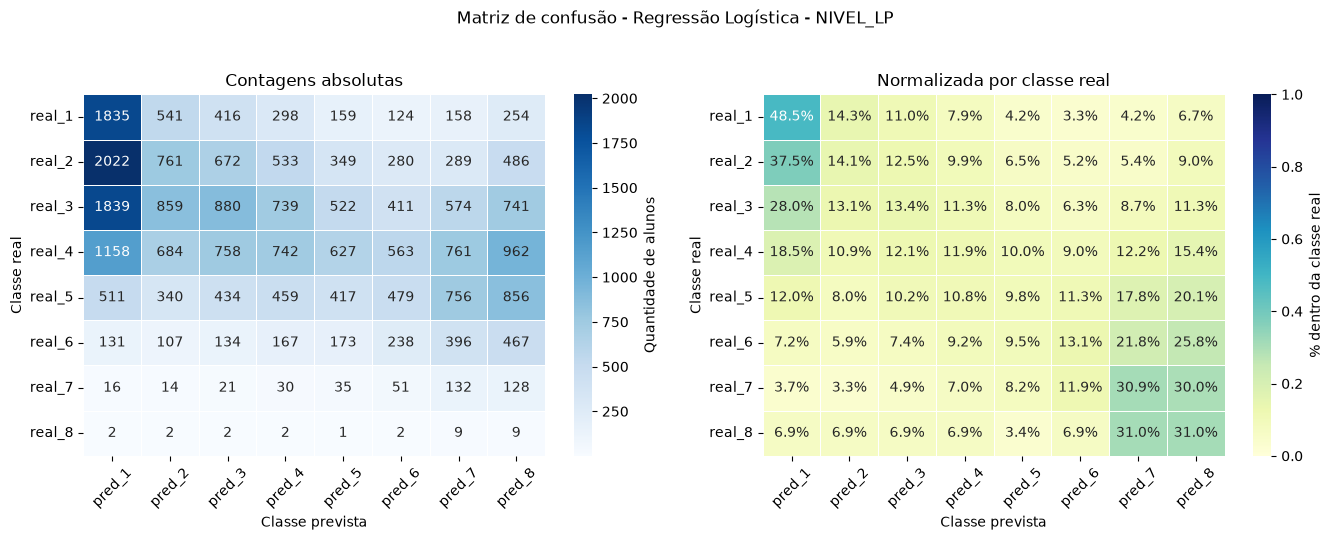

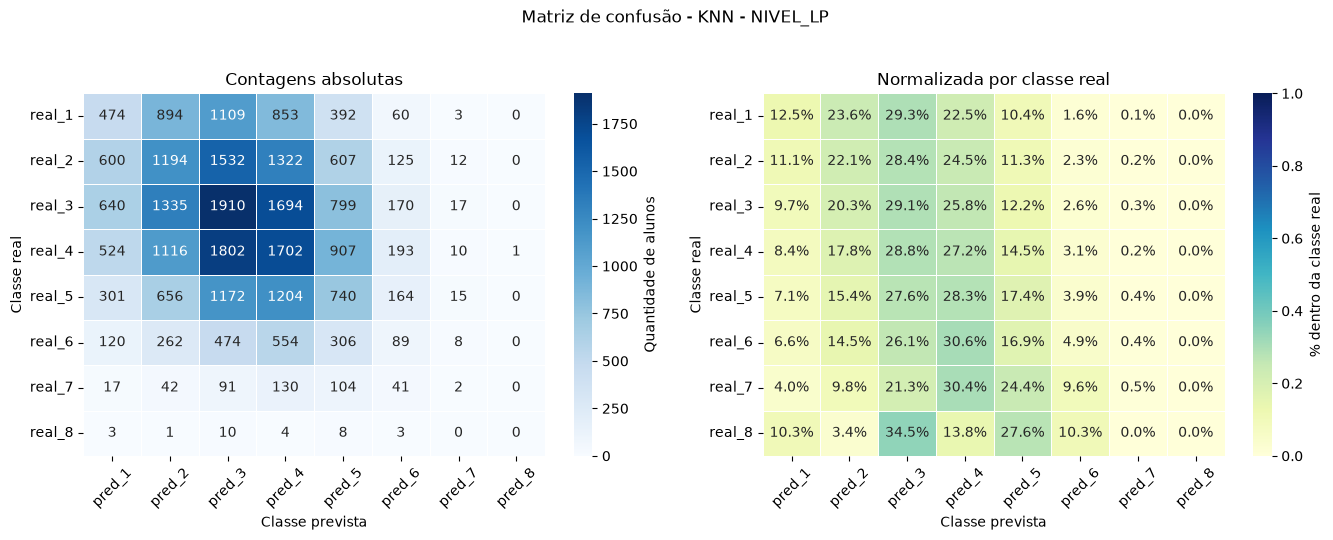

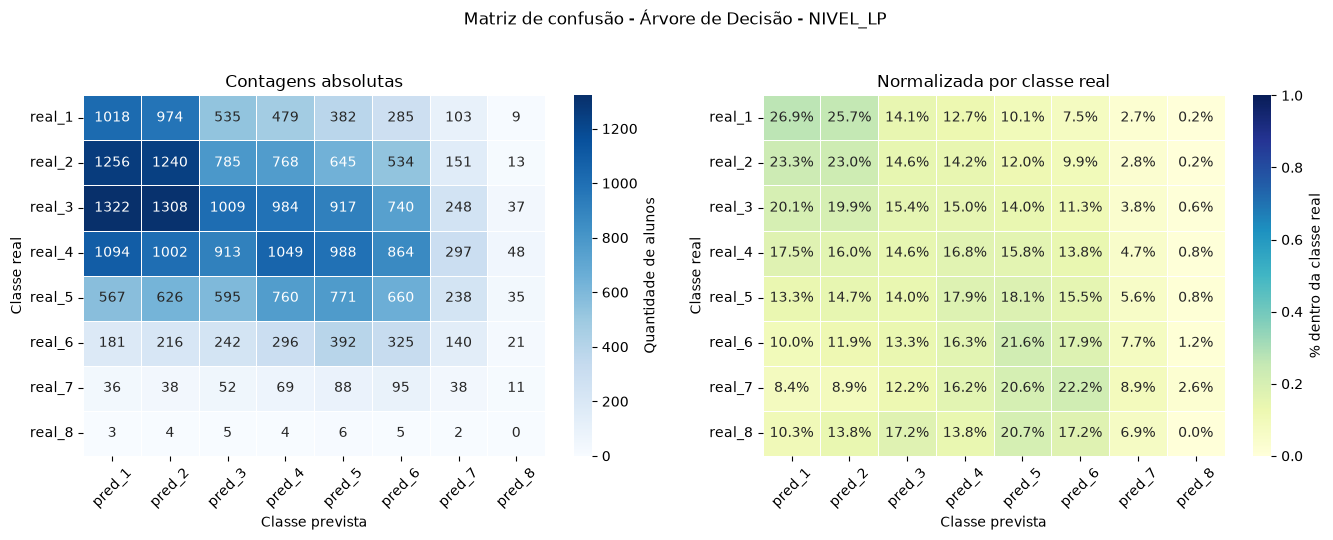

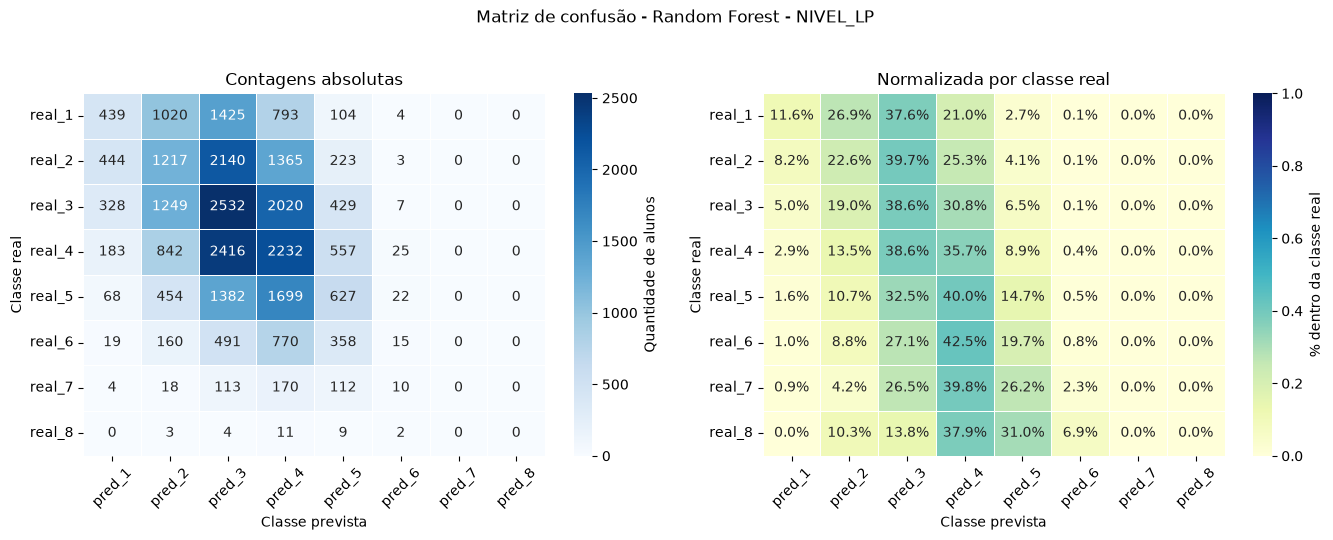

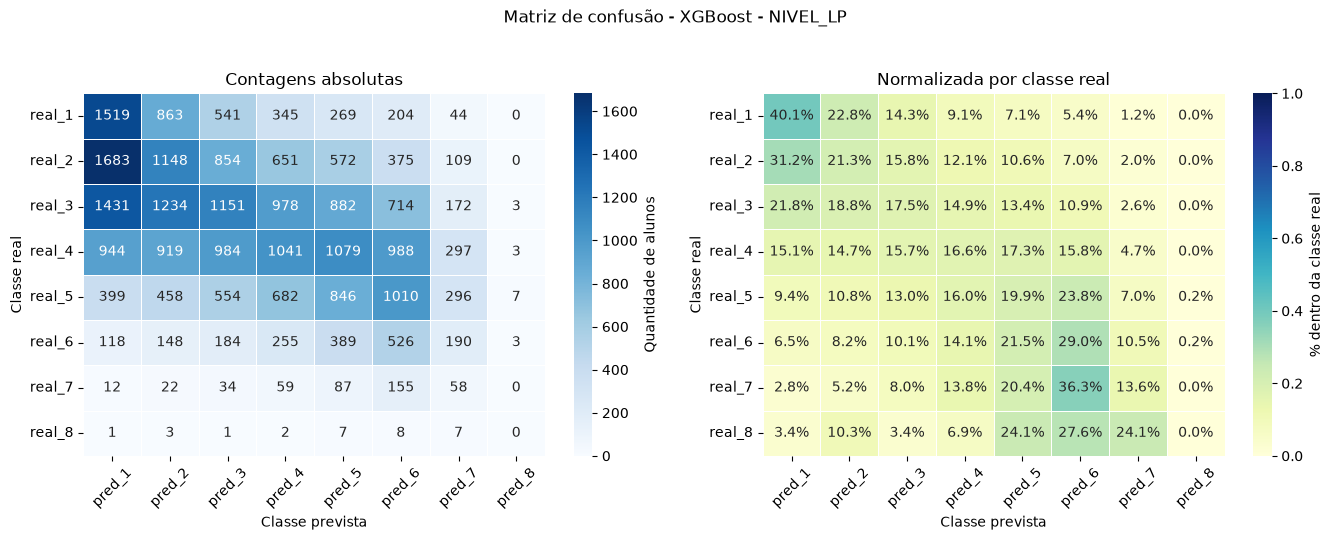

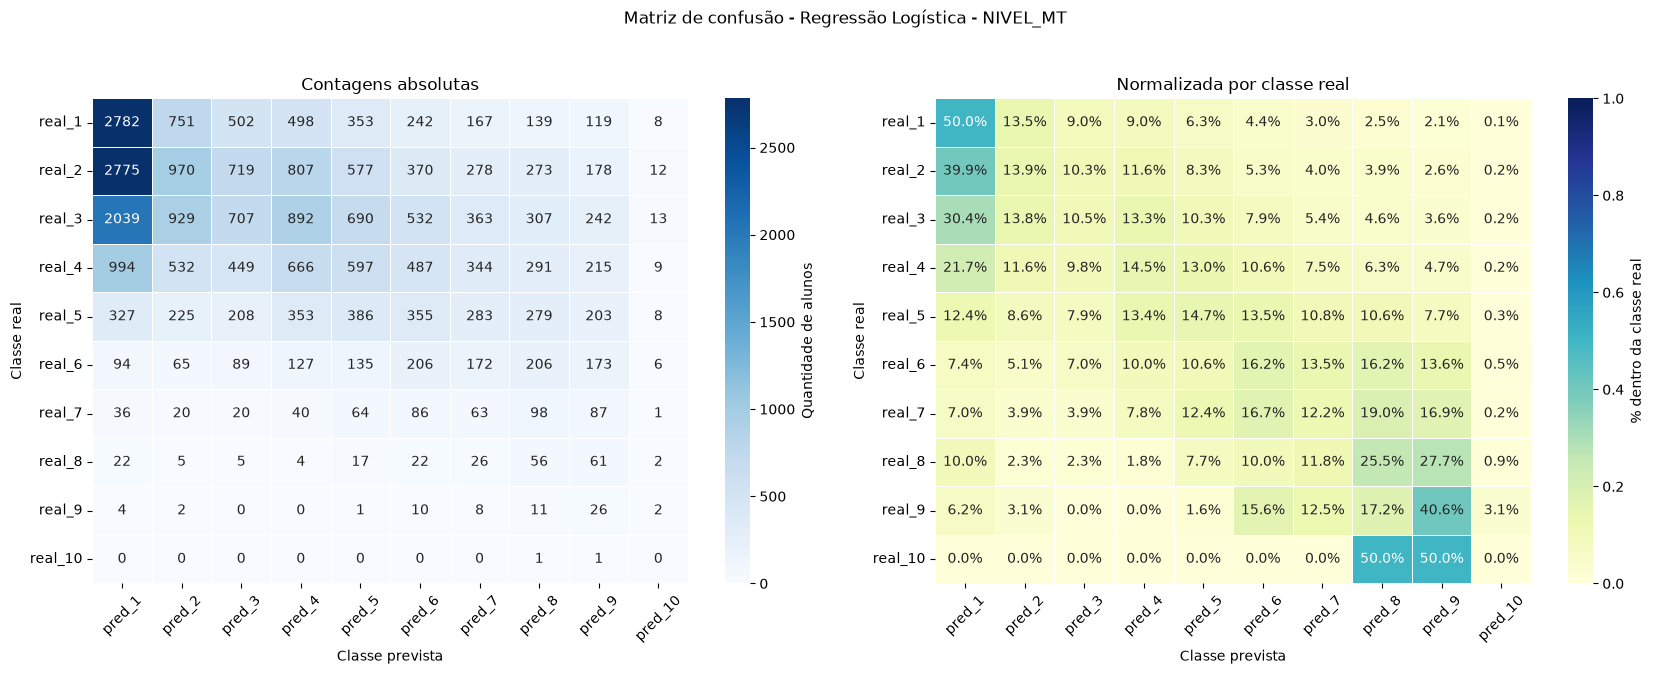

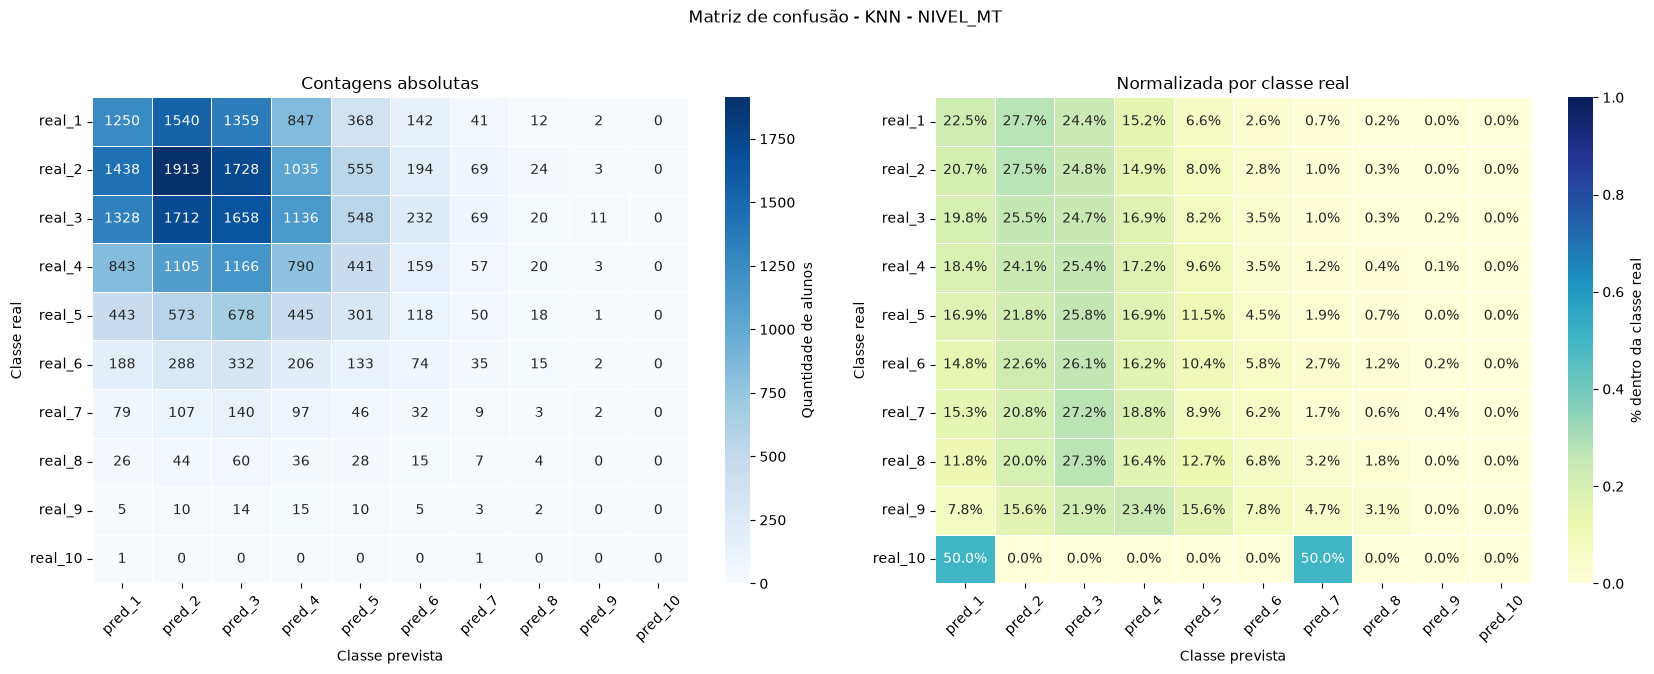

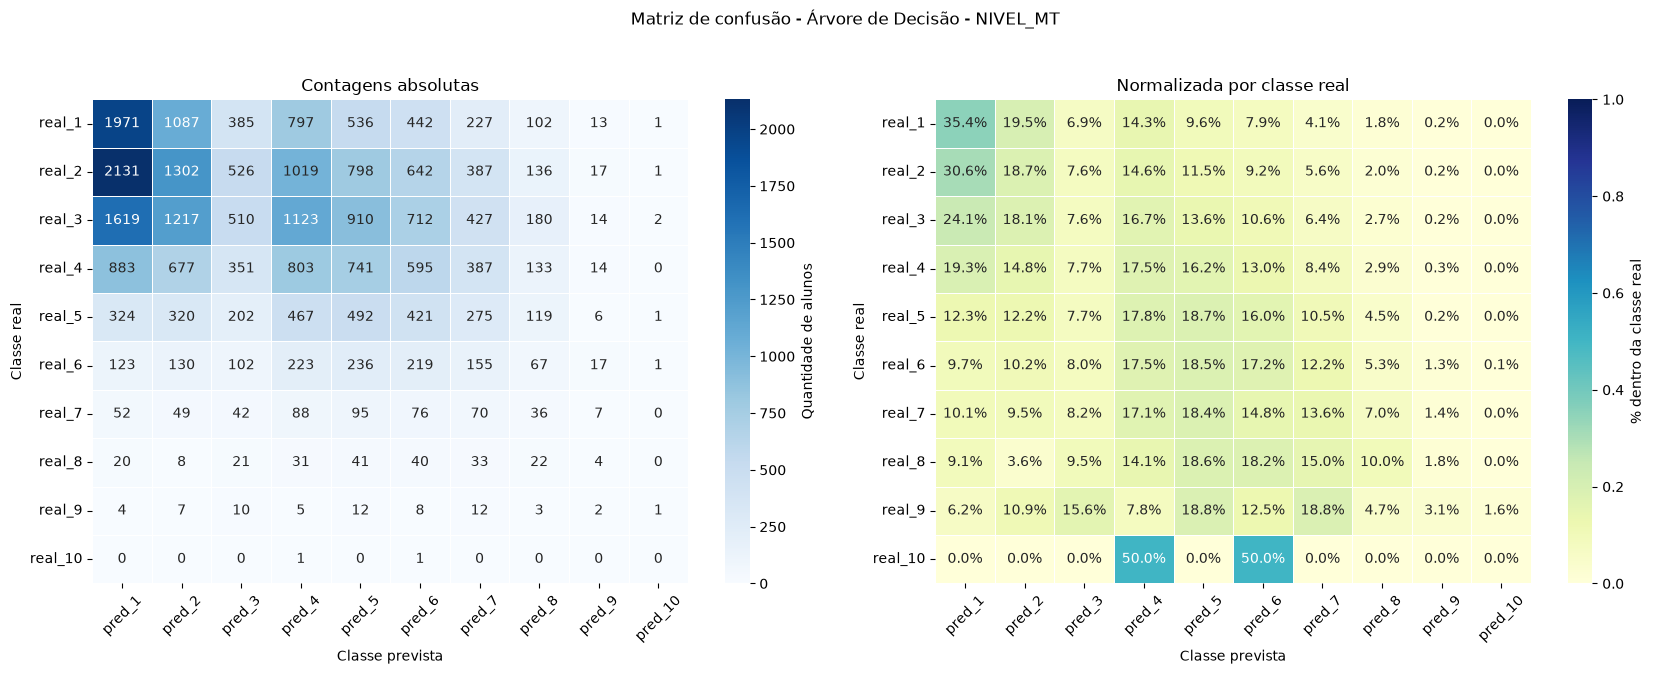

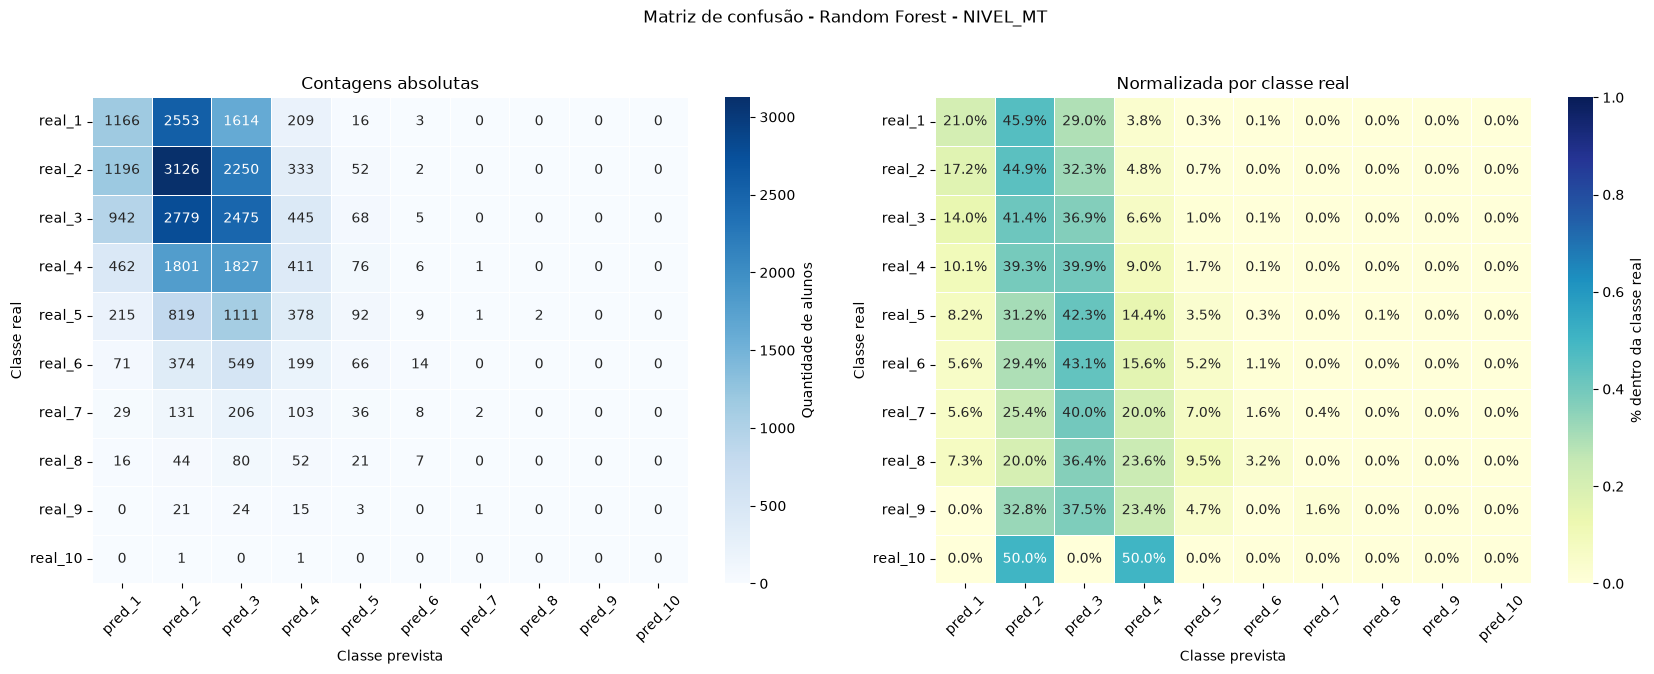

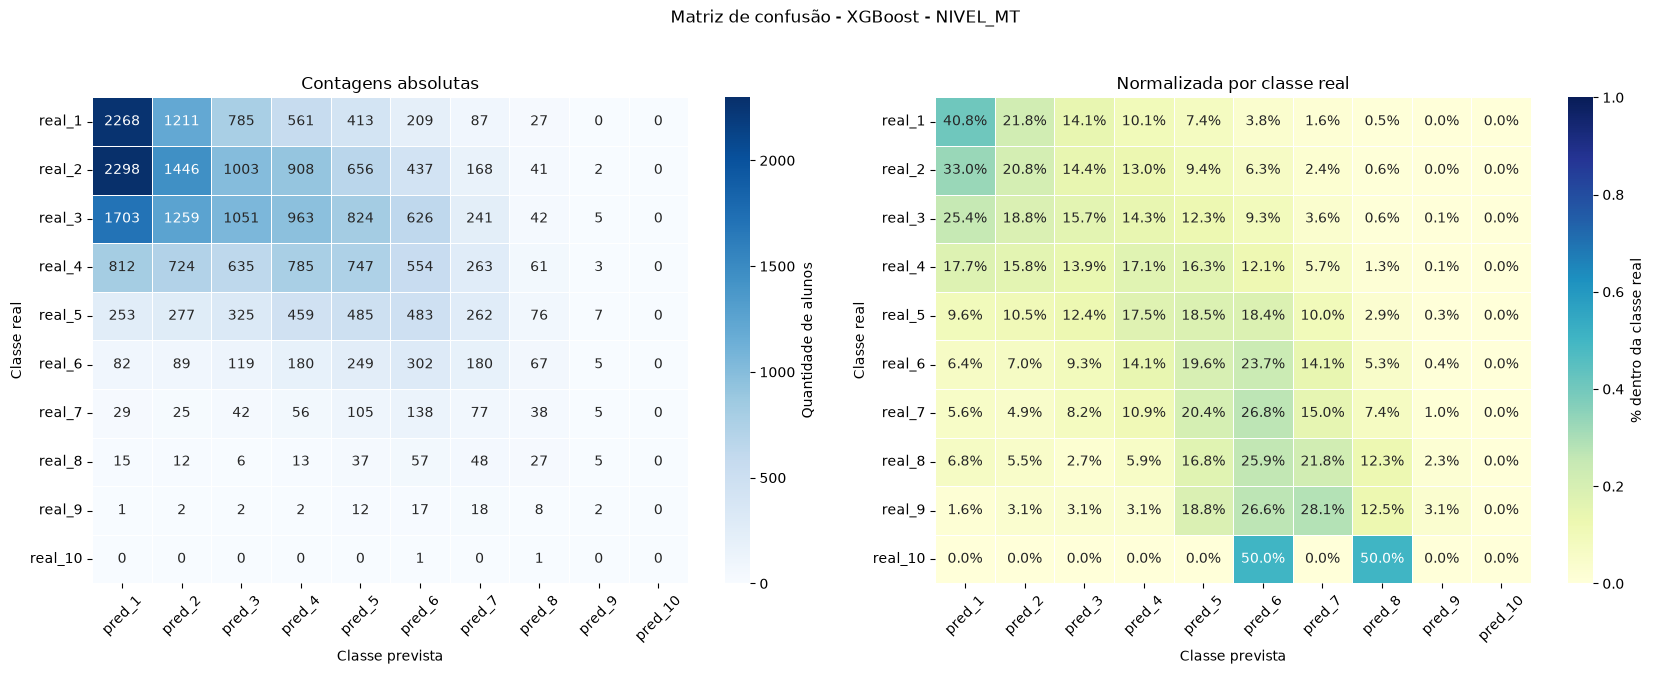

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "matrizes_confusao" not in globals():
    raise NameError("Execute primeiro a célula que monta matrizes_confusao.")


def plotar_matriz_confusao(alvo: str, nome_modelo: str, matriz: pd.DataFrame) -> None:
    matriz_absoluta = matriz.astype(int)
    totais_linha = matriz_absoluta.sum(axis=1).replace(0, np.nan)
    matriz_normalizada = matriz_absoluta.div(totais_linha, axis=0).fillna(0)

    largura = max(12, matriz_absoluta.shape[1] * 1.7)
    altura = max(4.5, matriz_absoluta.shape[0] * 0.65)
    figura, eixos = plt.subplots(1, 2, figsize=(largura, altura))

    sns.heatmap(
        matriz_absoluta,
        annot=True,
        fmt="d",
        cmap="Blues",
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "Quantidade de alunos"},
        ax=eixos[0],
    )
    eixos[0].set_title("Contagens absolutas")

    sns.heatmap(
        matriz_normalizada,
        annot=True,
        fmt=".1%",
        cmap="YlGnBu",
        vmin=0,
        vmax=1,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "% dentro da classe real"},
        ax=eixos[1],
    )
    eixos[1].set_title("Normalizada por classe real")

    for eixo in eixos:
        eixo.set_xlabel("Classe prevista")
        eixo.set_ylabel("Classe real")
        eixo.tick_params(axis="x", rotation=45)
        eixo.tick_params(axis="y", rotation=0)

    figura.suptitle(f"Matriz de confusão - {nome_modelo} - {alvo}", y=1.03)
    figura.tight_layout()
    plt.show()


for (alvo, nome_modelo), matriz in matrizes_confusao.items():
    plotar_matriz_confusao(alvo, nome_modelo, matriz)


## Inferências de exemplo

As inferências abaixo usam algumas linhas reais da base de modelagem apenas como exemplos de uso dos pipelines treinados. Para cada alvo e modelo, exibimos o valor real, a classe prevista e a maior probabilidade estimada quando o estimador oferece `predict_proba`.


In [26]:
amostras_inferencia = df_modelagem.sample(
    n=min(5, len(df_modelagem)),
    random_state=42,
).copy()

colunas_contexto = [
    coluna
    for coluna in ["ID_ALUNO", "ID_ESCOLA", "ID_UF", "ID_AREA", "IN_PUBLICA"]
    if coluna in amostras_inferencia.columns
]

linhas_inferencia = []

for alvo, resultados_alvo in resultados.items():
    for nome_modelo, resultado in resultados_alvo.items():
        pipeline = resultado.pipeline
        predicoes = pipeline.predict(amostras_inferencia)

        probabilidades = None
        if hasattr(pipeline, "predict_proba"):
            probabilidades = pipeline.predict_proba(amostras_inferencia)

        for posicao, indice in enumerate(amostras_inferencia.index):
            linha = {
                "alvo": alvo,
                "modelo": nome_modelo,
                "indice": indice,
                "valor_real": amostras_inferencia.loc[indice, alvo],
                "valor_previsto": predicoes[posicao],
            }

            for coluna in colunas_contexto:
                linha[coluna] = amostras_inferencia.loc[indice, coluna]

            if probabilidades is not None:
                linha["probabilidade_maxima"] = float(probabilidades[posicao].max())
                linha["classe_mais_provavel"] = pipeline.classes_[probabilidades[posicao].argmax()]

            linhas_inferencia.append(linha)

inferencias_exemplo = pd.DataFrame(linhas_inferencia)
inferencias_exemplo


,alvo,modelo,indice,valor_real,valor_previsto,ID_ALUNO,ID_ESCOLA,ID_UF,ID_AREA,IN_PUBLICA,probabilidade_maxima,classe_mais_provavel
0,NIVEL_LP,Regressão Logística,402835,3,1,51022291,61435685,25,1.0,1,0.480943,1
1,NIVEL_LP,Regressão Logística,1287327,2,8,54945104,61444447,41,1.0,1,0.285894,8
2,NIVEL_LP,Regressão Logística,1044720,6,8,53925706,61407401,35,1.0,1,0.485424,8
3,NIVEL_LP,Regressão Logística,1513075,4,1,56419479,61470211,53,0.0,1,0.200034,1
4,NIVEL_LP,Regressão Logística,1215025,5,8,54899279,61461453,41,1.0,1,0.184389,8
5,NIVEL_LP,KNN,402835,3,3,51022291,61435685,25,1.0,1,1.000000,3
6,NIVEL_LP,KNN,1287327,2,2,54945104,61444447,41,1.0,1,1.000000,2
7,NIVEL_LP,KNN,1044720,6,6,53925706,61407401,35,1.0,1,1.000000,6
8,NIVEL_LP,KNN,1513075,4,4,56419479,61470211,53,0.0,1,1.000000,4
9,NIVEL_LP,KNN,1215025,5,5,54899279,61461453,41,1.0,1,1.000000,5


## Como usar um pipeline treinado

Os pipelines ficam guardados em `resultados[alvo][modelo].pipeline`. O exemplo abaixo mostra uma chamada direta para obter predições e probabilidades de um modelo específico.


In [27]:
alvo_exemplo = "NIVEL_LP"
modelo_exemplo = "XGBoost"

pipeline_exemplo = resultados[alvo_exemplo][modelo_exemplo].pipeline

predicao_exemplo = pipeline_exemplo.predict(amostras_inferencia.head(1))[0]
probabilidades_exemplo = pd.Series(
    pipeline_exemplo.predict_proba(amostras_inferencia.head(1))[0],
    index=pipeline_exemplo.classes_,
    name="probabilidade",
)

print(f"Modelo: {modelo_exemplo}")
print(f"Alvo: {alvo_exemplo}")
print(f"Predição: {predicao_exemplo}")
print("Probabilidades por classe:")
display(probabilidades_exemplo.to_frame())


Modelo: XGBoost
Alvo: NIVEL_LP
Predição: 3
Probabilidades por classe:


,probabilidade
1,0.227348
2,0.146620
3,0.450005
4,0.106332
5,0.049916
6,0.017655
7,0.002048
8,0.000078


# Conclusão

Os modelos treinados conseguiram capturar algum sinal real dos dados, mas os resultados indicam que a tarefa é difícil para uma classificação individual precisa dos níveis SAEB. O melhor desempenho em termos de F1-macro foi obtido pelo XGBoost nos dois alvos: para Língua Portuguesa, `accuracy_teste` de aproximadamente **22,1%** e `f1_macro_teste` de **17,5%**; para Matemática, `accuracy_teste` de aproximadamente **22,6%** e `f1_macro_teste` de **14,9%**. Esses valores não são altos em termos absolutos, especialmente porque a aplicação final seria prever o nível de proficiência de um aluno específico. Ainda assim, eles são claramente superiores a um classificador aleatório uniforme, que teria expectativa aproximada de **12,5%** de acerto em Língua Portuguesa, considerando 8 níveis ativos, e **10,0%** em Matemática, considerando 10 níveis ativos.

A comparação com baselines simples precisa ser feita com cuidado. A acurácia pode parecer melhor em alguns modelos, como no Random Forest para Matemática, que chegou a cerca de **25,5%** de acerto, mas seu `f1_macro_teste` ficou em apenas **10,8%**. Isso sugere que parte desse ganho vem de privilegiar classes mais frequentes, e não necessariamente de reconhecer bem todas as faixas de proficiência. Por isso, o F1-macro e o recall por classe são métricas mais importantes neste problema: eles penalizam modelos que acertam razoavelmente as classes majoritárias, mas ignoram níveis raros, como os níveis mais altos de Matemática.

A principal hipótese para o desempenho moderado é que as variáveis disponíveis descrevem muito mais o contexto socioeconômico, escolar e administrativo do que o conhecimento efetivo do estudante no momento da prova. Fatores como infraestrutura da escola, características declaradas em questionários e indicadores agregados ajudam a estimar tendências gerais de desempenho, mas não carregam informação suficiente para separar com precisão alunos em muitos níveis adjacentes de proficiência. Além disso, os níveis SAEB são faixas discretizadas de uma proficiência contínua: um aluno próximo ao limite entre dois níveis pode ser classificado em uma categoria diferente por pequena variação na nota, e o modelo é penalizado da mesma forma tanto por errar por um nível quanto por errar por vários níveis.

Outro fator importante é o desbalanceamento das classes. A distribuição dos níveis não é uniforme: há concentração nos níveis intermediários e poucos exemplos nas extremidades, especialmente nos níveis mais altos. Isso torna difícil aprender padrões robustos para as classes raras e tende a reduzir recall e F1-macro. As matrizes de confusão ajudam a visualizar esse comportamento: quando os erros se concentram próximos da diagonal, o modelo ainda está capturando uma ordem aproximada de desempenho; quando há concentração em poucas colunas, o modelo está apenas reproduzindo a frequência das classes dominantes.

Também é relevante destacar que o processo removeu variáveis com alto risco de vazamento de informação, como proficiências diretas e médias de desempenho muito próximas dos alvos. Essa escolha torna a avaliação mais honesta, mas reduz bastante o poder preditivo. Além disso, a validação agrupada por `ID_ESCOLA` torna o teste mais exigente, pois avalia a capacidade de generalizar para grupos escolares distintos, em vez de apenas memorizar padrões específicos de escolas vistas no treinamento.

Portanto, a conclusão é que os modelos não são suficientemente precisos para uso como ferramenta individual de classificação de nível SAEB, mas demonstram que existe sinal estatístico relevante nos dados contextuais. O desempenho acima do aleatório indica que características socioeconômicas e escolares estão associadas aos níveis de proficiência, embora expliquem apenas parte da variação observada. Para melhorar o resultado, próximos trabalhos poderiam testar uma formulação ordinal do problema, agrupar os níveis em faixas mais amplas, prever a proficiência contínua antes de convertê-la em nível, calibrar melhor o tratamento de classes raras e incluir variáveis pedagógicas mais diretamente ligadas à aprendizagem, desde que não introduzam vazamento do alvo.
